<a href="https://colab.research.google.com/github/pandeychetanya/HalloweenFlutter/blob/main/two_band.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
Loaded: /content/drive/MyDrive/steer_search_PD/main_sequence_outputs/all_saccades_s189.csv
Original shape: (1913, 34)

Robust double-linear band classification complete
------------------------------------------------
Converged: True
Iterations: 10
Valid saccades classified: 1913

Low-dot line:
  duration_ms = 30.8080 + 1.6934 * amplitude_deg

High-dot line:
  duration_ms = 47.0080 + 2.0748 * amplitude_deg

Band counts:
band_label
low-dot     1045
high-dot     868
Name: count, dtype: int64

Band margin summary:
count    1913.000000
mean      106.188543
std        48.982709
min         0.361413
25%        68.650253
50%       113.739450
75%       145.713101
max       212.846507
Name: band_margin, dtype: float64


/tmp/ipykernel_18253/3680779454.py:298: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['low-dot' 'high-dot' 'low-dot' ... 'high-dot' 'high-dot' 'low-dot']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_out.loc[valid, "band_label"] = band_label



Saved:
/content/drive/MyDrive/steer_search_PD/main_sequence_outputs/all_saccades_s189_band_robust_double_linear.csv
New shape: (1913, 36)


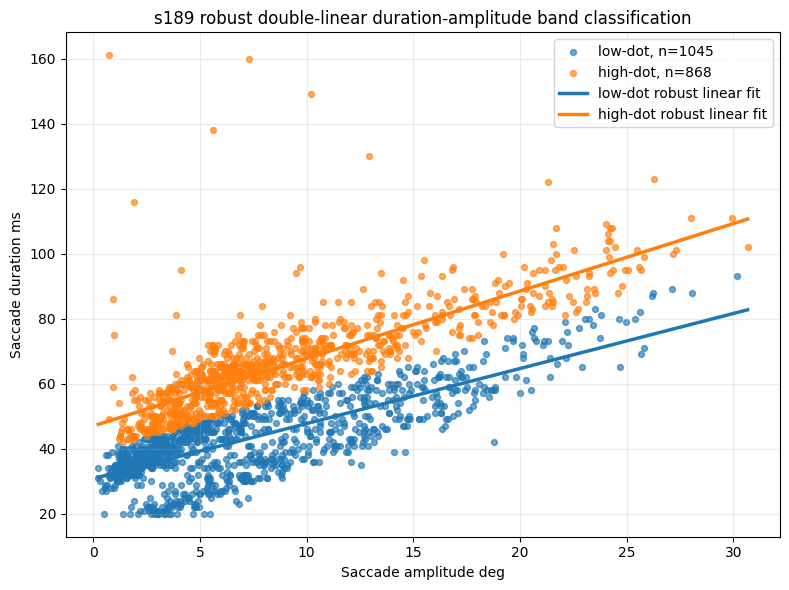

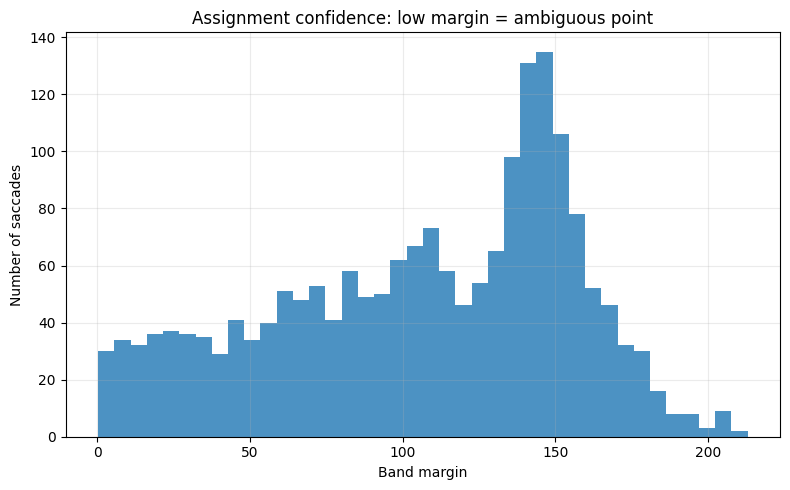

,subject_id,group,block_id,trial,image,stim_id,rt_ms,rt_from_response_ms,saccade_index,trace_key,...,winsize,min_saccade_speed_deg_s,drift_min_duration_ms,calib_session_id,n_trial_samples,valid_fraction,blink_fraction,n_blink_samples,band_label,band_margin
0,s189,Control,250807_170121,1,044.jpg,250807_170121_044.jpg,2971.0,2970.404,0,s189|250807_170121|1|0,...,13,50.0,100.0,0,2972,1.0,0.0,0,low-dot,88.392936
1,s189,Control,250807_170121,1,044.jpg,250807_170121_044.jpg,2971.0,2970.404,1,s189|250807_170121|1|1,...,13,50.0,100.0,0,2972,1.0,0.0,0,high-dot,124.979239
2,s189,Control,250807_170121,1,044.jpg,250807_170121_044.jpg,2971.0,2970.404,2,s189|250807_170121|1|2,...,13,50.0,100.0,0,2972,1.0,0.0,0,low-dot,179.539486
3,s189,Control,250807_170121,1,044.jpg,250807_170121_044.jpg,2971.0,2970.404,3,s189|250807_170121|1|3,...,13,50.0,100.0,0,2972,1.0,0.0,0,low-dot,117.139438
4,s189,Control,250807_170121,1,044.jpg,250807_170121_044.jpg,2971.0,2970.404,4,s189|250807_170121|1|4,...,13,50.0,100.0,0,2972,1.0,0.0,0,low-dot,41.103285


In [2]:
# ============================================================
# Robust double-linear band classifier
#
# Model:
#   low band:  duration_ms = a_low  + b_low  * amplitude_deg
#   high band: duration_ms = a_high + b_high * amplitude_deg
#
# Uses Huber loss instead of MSE for assignment.
# Better than MSE because large outliers do not dominate.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from google.colab import drive
drive.mount("/content/drive", force_remount=True)

# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------

CSV_PATH = Path(
    "/content/drive/MyDrive/steer_search_PD/main_sequence_outputs/all_saccades_s189.csv"
)

OUT_PATH = CSV_PATH.with_name("all_saccades_s189_band_robust_double_linear.csv")

assert CSV_PATH.exists(), f"Missing file: {CSV_PATH}"

# ------------------------------------------------------------
# 2. Load data
# ------------------------------------------------------------

df = pd.read_csv(CSV_PATH)

required_cols = ["amplitude_deg", "duration_ms"]
missing_cols = [c for c in required_cols if c not in df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

print("Loaded:", CSV_PATH)
print("Original shape:", df.shape)

# ------------------------------------------------------------
# 3. Linear design matrix
# ------------------------------------------------------------

def _make_linear_design_matrix(amplitude_deg):
    """
    Linear model:
        duration_ms = a + b * amplitude_deg
    """

    amp = np.asarray(amplitude_deg, dtype=float)

    X = np.column_stack([
        np.ones_like(amp),
        amp
    ])

    return X


# ------------------------------------------------------------
# 4. Huber loss
# ------------------------------------------------------------

def huber_loss(residual, delta):
    """
    Huber loss.

    For small residuals:
        behaves like squared error

    For large residuals:
        behaves like absolute error

    This makes it more robust than MSE.
    """

    r = np.asarray(residual, dtype=float)
    abs_r = np.abs(r)

    loss = np.where(
        abs_r <= delta,
        0.5 * r**2,
        delta * (abs_r - 0.5 * delta)
    )

    return loss


# ------------------------------------------------------------
# 5. Robust linear fit using iteratively reweighted least squares
# ------------------------------------------------------------

def robust_linear_fit_huber(amplitude_deg, duration_ms, delta=8.0, max_iter=50):
    """
    Fits:
        duration_ms = a + b * amplitude_deg

    using Huber robust regression.

    delta is in ms.
    Smaller delta = more robust, less sensitive to outliers.
    """

    X = _make_linear_design_matrix(amplitude_deg)
    y = np.asarray(duration_ms, dtype=float)

    # Initial ordinary least squares fit
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)

    for _ in range(max_iter):
        pred = X @ beta
        resid = y - pred
        abs_resid = np.abs(resid)

        # Huber weights
        weights = np.ones_like(abs_resid)
        big = abs_resid > delta
        weights[big] = delta / abs_resid[big]

        # Weighted least squares
        W = np.sqrt(weights)
        Xw = X * W[:, None]
        yw = y * W

        beta_new, *_ = np.linalg.lstsq(Xw, yw, rcond=None)

        if np.allclose(beta, beta_new, rtol=1e-6, atol=1e-6):
            beta = beta_new
            break

        beta = beta_new

    return beta


def predict_linear(amplitude_deg, beta):
    X = _make_linear_design_matrix(amplitude_deg)
    return X @ beta


# ------------------------------------------------------------
# 6. Robust double-linear classifier
# ------------------------------------------------------------

def classify_saccade_band_robust_double_linear(
    dataframe_saccades,
    delta_fit=8.0,
    delta_assign=8.0,
    max_iter=50,
    min_per_band=10,
    verbose=True
):
    """
    Classifies saccades into lower and upper duration-amplitude bands.

    Uses two robust linear models:
        duration_ms = a + b * amplitude_deg

    Assignment uses Huber loss instead of MSE.

    Adds:
        band_label
        band_margin

    band_margin:
        positive value = stronger confidence
        near 0 = ambiguous point
    """

    df_out = dataframe_saccades.copy()

    valid = (
        df_out["amplitude_deg"].notna()
        & df_out["duration_ms"].notna()
        & np.isfinite(df_out["amplitude_deg"])
        & np.isfinite(df_out["duration_ms"])
        & (df_out["amplitude_deg"] > 0)
        & (df_out["duration_ms"] > 0)
    )

    fit_df = df_out.loc[valid].copy()

    if len(fit_df) < 2 * min_per_band:
        raise ValueError(
            f"Not enough valid saccades. Need at least {2 * min_per_band}, "
            f"got {len(fit_df)}."
        )

    amp = fit_df["amplitude_deg"].to_numpy(dtype=float)
    dur = fit_df["duration_ms"].to_numpy(dtype=float)

    # --------------------------------------------------------
    # Initial split:
    # Fit one global robust line, then split by residual median
    # --------------------------------------------------------

    beta_global = robust_linear_fit_huber(
        amp,
        dur,
        delta=delta_fit,
        max_iter=max_iter
    )

    pred_global = predict_linear(amp, beta_global)
    residual_global = dur - pred_global

    labels = np.where(
        residual_global <= np.median(residual_global),
        0,
        1
    )

    converged = False

    # --------------------------------------------------------
    # Iteratively fit two robust lines and reassign points
    # --------------------------------------------------------

    for iteration in range(max_iter):

        old_labels = labels.copy()

        n0 = np.sum(labels == 0)
        n1 = np.sum(labels == 1)

        if n0 < min_per_band or n1 < min_per_band:
            raise ValueError(
                f"One band collapsed: n0={n0}, n1={n1}. "
                f"Try reducing min_per_band or increasing delta_assign."
            )

        beta0 = robust_linear_fit_huber(
            amp[labels == 0],
            dur[labels == 0],
            delta=delta_fit,
            max_iter=max_iter
        )

        beta1 = robust_linear_fit_huber(
            amp[labels == 1],
            dur[labels == 1],
            delta=delta_fit,
            max_iter=max_iter
        )

        pred0 = predict_linear(amp, beta0)
        pred1 = predict_linear(amp, beta1)

        loss0 = huber_loss(dur - pred0, delta=delta_assign)
        loss1 = huber_loss(dur - pred1, delta=delta_assign)

        labels = np.where(loss0 <= loss1, 0, 1)

        if np.array_equal(labels, old_labels):
            converged = True
            break

    # --------------------------------------------------------
    # Decide which model is low-dot and which is high-dot
    # --------------------------------------------------------

    pred0_final = predict_linear(amp, beta0)
    pred1_final = predict_linear(amp, beta1)

    if np.mean(pred0_final) <= np.mean(pred1_final):
        beta_low = beta0
        beta_high = beta1
    else:
        beta_low = beta1
        beta_high = beta0

    pred_low = predict_linear(amp, beta_low)
    pred_high = predict_linear(amp, beta_high)

    loss_low = huber_loss(dur - pred_low, delta=delta_assign)
    loss_high = huber_loss(dur - pred_high, delta=delta_assign)

    band_label = np.where(
        loss_low <= loss_high,
        "low-dot",
        "high-dot"
    )

    # Confidence-like margin
    # Larger margin = clearer assignment
    band_margin = np.abs(loss_low - loss_high)

    df_out["band_label"] = np.nan
    df_out["band_margin"] = np.nan

    df_out.loc[valid, "band_label"] = band_label
    df_out.loc[valid, "band_margin"] = band_margin

    if verbose:
        print("\nRobust double-linear band classification complete")
        print("------------------------------------------------")
        print("Converged:", converged)
        print("Iterations:", iteration + 1)
        print("Valid saccades classified:", int(valid.sum()))
        print()
        print("Low-dot line:")
        print(f"  duration_ms = {beta_low[0]:.4f} + {beta_low[1]:.4f} * amplitude_deg")
        print()
        print("High-dot line:")
        print(f"  duration_ms = {beta_high[0]:.4f} + {beta_high[1]:.4f} * amplitude_deg")
        print()
        print("Band counts:")
        print(df_out["band_label"].value_counts(dropna=False))
        print()
        print("Band margin summary:")
        print(df_out["band_margin"].describe())

    return df_out, beta_low, beta_high


# ------------------------------------------------------------
# 7. Run robust double-linear classifier
# ------------------------------------------------------------

df_band, beta_low, beta_high = classify_saccade_band_robust_double_linear(
    df,
    delta_fit=8.0,
    delta_assign=8.0,
    max_iter=50,
    min_per_band=10,
    verbose=True
)

# ------------------------------------------------------------
# 8. Save output CSV
# ------------------------------------------------------------

df_band.to_csv(OUT_PATH, index=False)

print("\nSaved:")
print(OUT_PATH)
print("New shape:", df_band.shape)

# ------------------------------------------------------------
# 9. Plot result with fitted lines
# ------------------------------------------------------------

plot_df = df_band.dropna(subset=["band_label"]).copy()

low = plot_df[plot_df["band_label"] == "low-dot"]
high = plot_df[plot_df["band_label"] == "high-dot"]

amp_grid = np.linspace(
    plot_df["amplitude_deg"].min(),
    plot_df["amplitude_deg"].max(),
    200
)

low_line = predict_linear(amp_grid, beta_low)
high_line = predict_linear(amp_grid, beta_high)

plt.figure(figsize=(8, 6))

plt.scatter(
    low["amplitude_deg"],
    low["duration_ms"],
    s=18,
    alpha=0.65,
    label=f"low-dot, n={len(low)}"
)

plt.scatter(
    high["amplitude_deg"],
    high["duration_ms"],
    s=18,
    alpha=0.65,
    label=f"high-dot, n={len(high)}"
)

plt.plot(
    amp_grid,
    low_line,
    linewidth=2.5,
    label="low-dot robust linear fit"
)

plt.plot(
    amp_grid,
    high_line,
    linewidth=2.5,
    label="high-dot robust linear fit"
)

plt.xlabel("Saccade amplitude deg")
plt.ylabel("Saccade duration ms")
plt.title("s189 robust double-linear duration-amplitude band classification")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 10. Plot ambiguous points
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    plot_df["band_margin"].dropna(),
    bins=40,
    alpha=0.8
)

plt.xlabel("Band margin")
plt.ylabel("Number of saccades")
plt.title("Assignment confidence: low margin = ambiguous point")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

display(df_band.head())

In [3]:
# # ============================================================
# # Classify lower vs upper band in duration-vs-amplitude plot
# # for all_saccades_s189.csv
# #
# # Output:
# #   all_saccades_s189_band.csv
# #
# # Keeps ALL original columns and adds:
# #   band_label = "low-dot" or "high-dot"
# # ============================================================

# from pathlib import Path
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# # ------------------------------------------------------------
# # 1. Paths
# # ------------------------------------------------------------

# from google.colab import drive
# # drive.flush_and_unmount()

# drive.mount("/content/drive", force_remount=True)


# CSV_PATH = Path(
#     "/content/drive/MyDrive/steer_search_PD/main_sequence_outputs/all_saccades_s189.csv"
# )

# OUT_PATH = CSV_PATH.with_name("all_saccades_s189_band.csv")

# assert CSV_PATH.exists(), f"Missing file: {CSV_PATH}"

# # ------------------------------------------------------------
# # 2. Load data
# # ------------------------------------------------------------

# df = pd.read_csv(CSV_PATH)

# required_cols = ["amplitude_deg", "duration_ms"]
# missing_cols = [c for c in required_cols if c not in df.columns]

# if missing_cols:
#     raise ValueError(f"Missing required columns: {missing_cols}")

# print("Loaded:", CSV_PATH)
# print("Original shape:", df.shape)
# print("Original columns:", len(df.columns))

# # ------------------------------------------------------------
# # 3. Helper functions for curve fitting
# # ------------------------------------------------------------

# def _make_design_matrix(amplitude_deg, model="sqrt"):
#     """
#     Builds X matrix for duration-amplitude model.

#     model="sqrt":
#         duration_ms = a + b * sqrt(amplitude_deg)

#     model="linear":
#         duration_ms = a + b * amplitude_deg
#     """

#     amp = np.asarray(amplitude_deg, dtype=float)

#     if model == "sqrt":
#         x = np.sqrt(np.maximum(amp, 0))
#     elif model == "linear":
#         x = amp
#     else:
#         raise ValueError("model must be either 'sqrt' or 'linear'")

#     X = np.column_stack([
#         np.ones_like(x),
#         x
#     ])

#     return X


# def _fit_duration_curve(amplitude_deg, duration_ms, model="sqrt"):
#     """
#     Fits one duration-amplitude curve using least squares.
#     """

#     X = _make_design_matrix(amplitude_deg, model=model)
#     y = np.asarray(duration_ms, dtype=float)

#     beta, *_ = np.linalg.lstsq(X, y, rcond=None)

#     return beta


# def _predict_duration(amplitude_deg, beta, model="sqrt"):
#     """
#     Predicts duration_ms from amplitude_deg.
#     """

#     X = _make_design_matrix(amplitude_deg, model=model)
#     return X @ beta


# # ------------------------------------------------------------
# # 4. Main function requested
# # ------------------------------------------------------------

# def classify_saccade_band(
#     dataframe_saccades,
#     model="sqrt",
#     max_iter=50,
#     min_per_band=10,
#     verbose=True
# ):
#     """
#     Classifies each saccade as belonging to the lower or upper band
#     in the duration_ms vs amplitude_deg plot.

#     Parameters
#     ----------
#     dataframe_saccades : pd.DataFrame
#         Original saccade dataframe.
#         Must contain:
#             amplitude_deg
#             duration_ms

#     model : str
#         "sqrt" or "linear".

#     max_iter : int
#         Number of iterative fit/reassignment steps.

#     min_per_band : int
#         Minimum number of points required in each band.

#     verbose : bool
#         Whether to print fit information.

#     Returns
#     -------
#     df_out : pd.DataFrame
#         Original dataframe with all original columns preserved,
#         plus one new column:
#             band_label

#         band_label is:
#             "low-dot"
#             "high-dot"
#             NaN for invalid rows that could not be classified.
#     """

#     df_out = dataframe_saccades.copy()

#     # --------------------------------------------------------
#     # Only these rows are used for fitting/classification.
#     # Original rows are not removed.
#     # --------------------------------------------------------

#     valid = (
#         df_out["amplitude_deg"].notna()
#         & df_out["duration_ms"].notna()
#         & np.isfinite(df_out["amplitude_deg"])
#         & np.isfinite(df_out["duration_ms"])
#         & (df_out["amplitude_deg"] > 0)
#         & (df_out["duration_ms"] > 0)
#     )

#     fit_df = df_out.loc[valid].copy()

#     if len(fit_df) < 2 * min_per_band:
#         raise ValueError(
#             f"Not enough valid saccades to fit two bands. "
#             f"Need at least {2 * min_per_band}, got {len(fit_df)}."
#         )

#     amp = fit_df["amplitude_deg"].to_numpy(dtype=float)
#     dur = fit_df["duration_ms"].to_numpy(dtype=float)

#     # --------------------------------------------------------
#     # Step 1:
#     # Fit one global curve.
#     # Split points by residual around that global curve.
#     # --------------------------------------------------------

#     beta_global = _fit_duration_curve(amp, dur, model=model)
#     pred_global = _predict_duration(amp, beta_global, model=model)

#     residual_global = dur - pred_global

#     # Lower half starts as one band, upper half as other band.
#     labels = np.where(
#         residual_global <= np.median(residual_global),
#         0,
#         1
#     )

#     # --------------------------------------------------------
#     # Step 2:
#     # Iteratively fit two curves and reassign each point based
#     # on mean-squared error to each curve.
#     # --------------------------------------------------------

#     converged = False

#     for iteration in range(max_iter):

#         old_labels = labels.copy()

#         n0 = np.sum(labels == 0)
#         n1 = np.sum(labels == 1)

#         if n0 < min_per_band or n1 < min_per_band:
#             raise ValueError(
#                 f"One band collapsed during fitting: n0={n0}, n1={n1}. "
#                 f"Try model='linear', reduce min_per_band, or inspect outliers."
#             )

#         beta0 = _fit_duration_curve(
#             amp[labels == 0],
#             dur[labels == 0],
#             model=model
#         )

#         beta1 = _fit_duration_curve(
#             amp[labels == 1],
#             dur[labels == 1],
#             model=model
#         )

#         pred0 = _predict_duration(amp, beta0, model=model)
#         pred1 = _predict_duration(amp, beta1, model=model)

#         mse0 = (dur - pred0) ** 2
#         mse1 = (dur - pred1) ** 2

#         labels = np.where(mse0 <= mse1, 0, 1)

#         if np.array_equal(labels, old_labels):
#             converged = True
#             break

#     # --------------------------------------------------------
#     # Step 3:
#     # Decide which fitted curve is lower and which is upper.
#     # We compare average predicted duration across the observed
#     # amplitude range.
#     # --------------------------------------------------------

#     pred0_final = _predict_duration(amp, beta0, model=model)
#     pred1_final = _predict_duration(amp, beta1, model=model)

#     if np.mean(pred0_final) <= np.mean(pred1_final):
#         beta_low = beta0
#         beta_high = beta1
#     else:
#         beta_low = beta1
#         beta_high = beta0

#     # --------------------------------------------------------
#     # Step 4:
#     # Final classification based on squared error to low/high curve.
#     # --------------------------------------------------------

#     pred_low = _predict_duration(amp, beta_low, model=model)
#     pred_high = _predict_duration(amp, beta_high, model=model)

#     mse_low = (dur - pred_low) ** 2
#     mse_high = (dur - pred_high) ** 2

#     band_label = np.where(
#         mse_low <= mse_high,
#         "low-dot",
#         "high-dot"
#     )

#     # --------------------------------------------------------
#     # Step 5:
#     # Add only the requested band column.
#     # Keep all original columns unchanged.
#     # --------------------------------------------------------

#     df_out["band_label"] = np.nan
#     df_out.loc[valid, "band_label"] = band_label

#     if verbose:
#         print("\nBand classification complete")
#         print("----------------------------")
#         print("Model used:", model)
#         print("Converged:", converged)
#         print("Iterations:", iteration + 1)
#         print("Valid saccades classified:", int(valid.sum()))
#         print()
#         print("Low-dot curve:")
#         print(f"  duration_ms = {beta_low[0]:.4f} + {beta_low[1]:.4f} * {'sqrt(amplitude_deg)' if model == 'sqrt' else 'amplitude_deg'}")
#         print()
#         print("High-dot curve:")
#         print(f"  duration_ms = {beta_high[0]:.4f} + {beta_high[1]:.4f} * {'sqrt(amplitude_deg)' if model == 'sqrt' else 'amplitude_deg'}")
#         print()
#         print("Band counts:")
#         print(df_out["band_label"].value_counts(dropna=False))

#     return df_out


# # ------------------------------------------------------------
# # 5. Run classifier
# # ------------------------------------------------------------

# # Change this to "linear" if you want linear curves instead.
# MODEL = "sqrt"

# df_band = classify_saccade_band(
#     df,
#     model=MODEL,
#     max_iter=50,
#     min_per_band=10,
#     verbose=True
# )

# # ------------------------------------------------------------
# # 6. Save new CSV
# # ------------------------------------------------------------

# df_band.to_csv(OUT_PATH, index=False)

# print("\nSaved new CSV:")
# print(OUT_PATH)
# print("New shape:", df_band.shape)
# print("New columns:", len(df_band.columns))

# # ------------------------------------------------------------
# # 7. Quick plot to visually check classification
# # ------------------------------------------------------------

# plot_df = df_band.dropna(subset=["band_label"]).copy()

# low = plot_df[plot_df["band_label"] == "low-dot"]
# high = plot_df[plot_df["band_label"] == "high-dot"]

# plt.figure(figsize=(8, 6))

# plt.scatter(
#     low["amplitude_deg"],
#     low["duration_ms"],
#     s=18,
#     alpha=0.65,
#     label=f"low-dot, n={len(low)}"
# )

# plt.scatter(
#     high["amplitude_deg"],
#     high["duration_ms"],
#     s=18,
#     alpha=0.65,
#     label=f"high-dot, n={len(high)}"
# )

# plt.xlabel("Saccade amplitude deg")
# plt.ylabel("Saccade duration ms")
# plt.title(f"s189 duration vs amplitude band classification, model={MODEL}")
# plt.legend()
# plt.grid(alpha=0.25)
# plt.tight_layout()
# plt.show()

# # ------------------------------------------------------------
# # 8. Display first rows
# # ------------------------------------------------------------

# display(df_band.head())

Loaded band CSV: /content/drive/MyDrive/steer_search_PD/main_sequence_outputs/all_saccades_s189_band.csv
Saccade rows: 1913

Loaded trace bank: /content/drive/MyDrive/steer_search_PD/main_sequence_outputs/s189_trace_bank.pkl
Trace bank entries: 1913

Band counts:
band_label
low-dot     1047
high-dot     866
Name: count, dtype: int64

Trace keys matching trace bank: 1913 / 1913

Extracted trace samples: (197651, 12)
Skipped traces: 0


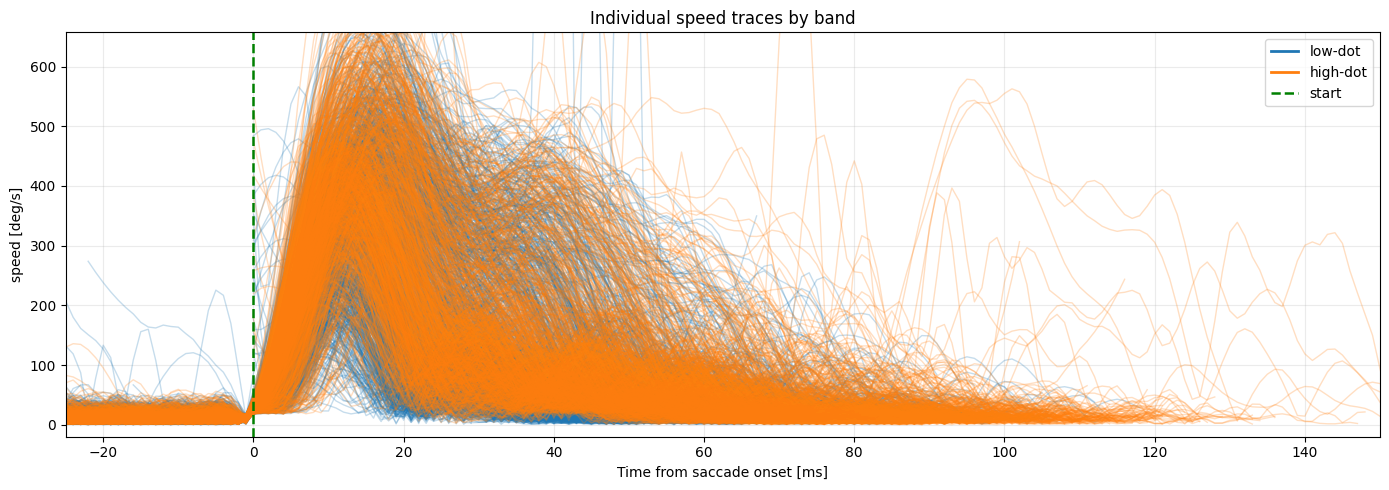

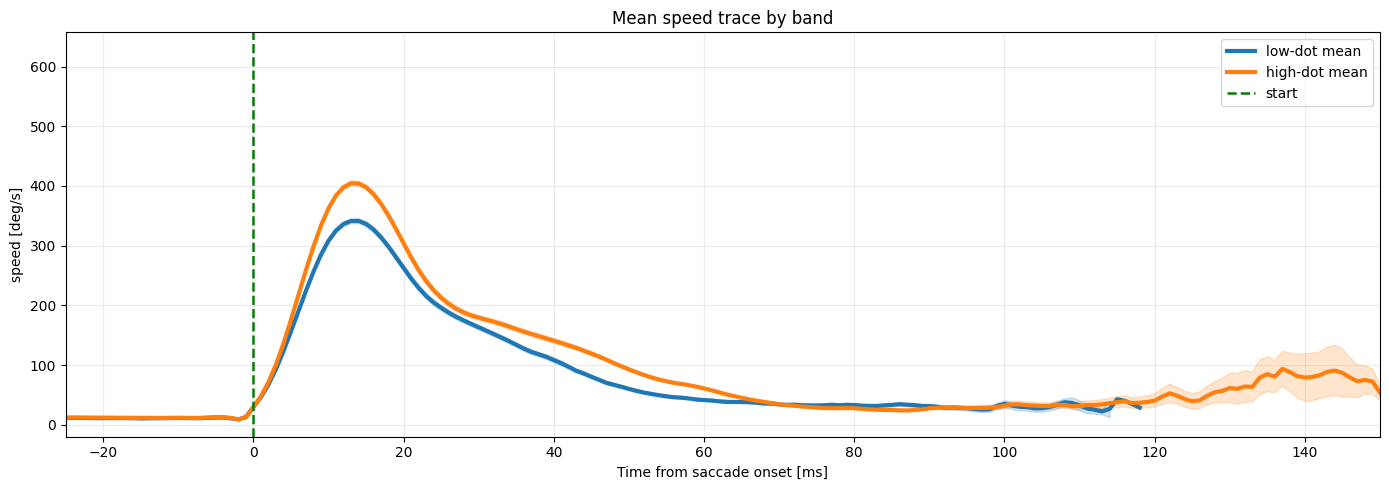

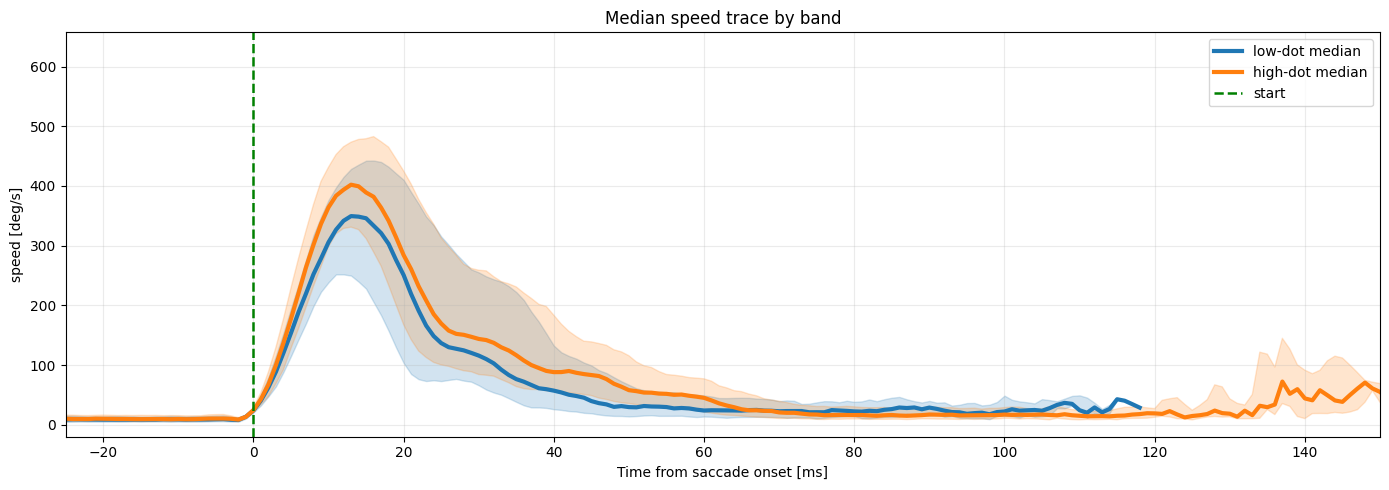


Per-trace summary by band:


,n,median_duration_ms,median_amplitude_deg,median_peak_velocity_csv,median_max_speed_window,mean_max_speed_window
band_label,,,,,,
high-dot,866,64.0,7.101626,436.543757,436.543757,449.214902
low-dot,1047,41.0,5.674452,389.583843,389.583843,383.855152



Returned traces_df:
(197651, 13)


,saccade_row,trace_key,band_label,rel_time_ms,speed_deg_s,duration_ms,amplitude_deg,peak_velocity_deg_s,block_id,trial,image,saccade_index,_rel_time_bin_ms
0,0,s189|250807_170121|1|0,low-dot,-25.0,9.062720,39.0,3.539195,343.028372,250807_170121,1,044.jpg,0,-25
1,0,s189|250807_170121|1|0,low-dot,-24.0,15.826920,39.0,3.539195,343.028372,250807_170121,1,044.jpg,0,-24
2,0,s189|250807_170121|1|0,low-dot,-23.0,18.298985,39.0,3.539195,343.028372,250807_170121,1,044.jpg,0,-23
3,0,s189|250807_170121|1|0,low-dot,-22.0,18.307383,39.0,3.539195,343.028372,250807_170121,1,044.jpg,0,-22
4,0,s189|250807_170121|1|0,low-dot,-21.0,17.837236,39.0,3.539195,343.028372,250807_170121,1,044.jpg,0,-21



Returned trace_summary:
(1913, 6)


,trace_key,band_label,max_speed_window_deg_s,duration_ms,amplitude_deg,peak_velocity_deg_s
0,s189|250807_170121|100|0,low-dot,375.499964,28.0,6.240930,375.499964
1,s189|250807_170121|100|1,high-dot,549.394119,84.0,18.362225,549.394119
2,s189|250807_170121|100|2,high-dot,308.794981,53.0,4.397271,308.794981
3,s189|250807_170121|100|3,low-dot,274.780295,32.0,2.041738,274.780295
4,s189|250807_170121|100|4,high-dot,212.580020,49.0,1.442575,212.580020


,amp_bin,band_label,n,mean_amp,mean_duration,mean_speed
0,"(0.0, 2.0]",high-dot,31,1.505916,55.612903,30.366724
1,"(0.0, 2.0]",low-dot,137,1.377617,33.598540,41.246901
2,"(2.0, 4.0]",high-dot,121,3.183400,51.413223,62.174052
3,"(2.0, 4.0]",low-dot,237,2.946968,35.316456,88.624809
4,"(4.0, 6.0]",high-dot,180,5.097502,58.616667,88.035187
5,"(4.0, 6.0]",low-dot,164,4.948259,38.000000,138.896880
6,"(6.0, 8.0]",high-dot,157,6.913387,64.197452,109.103411
7,"(6.0, 8.0]",low-dot,122,6.964782,40.188525,180.819980
8,"(8.0, 10.0]",high-dot,95,8.993759,67.673684,133.874660
9,"(8.0, 10.0]",low-dot,90,8.904028,43.944444,208.593283


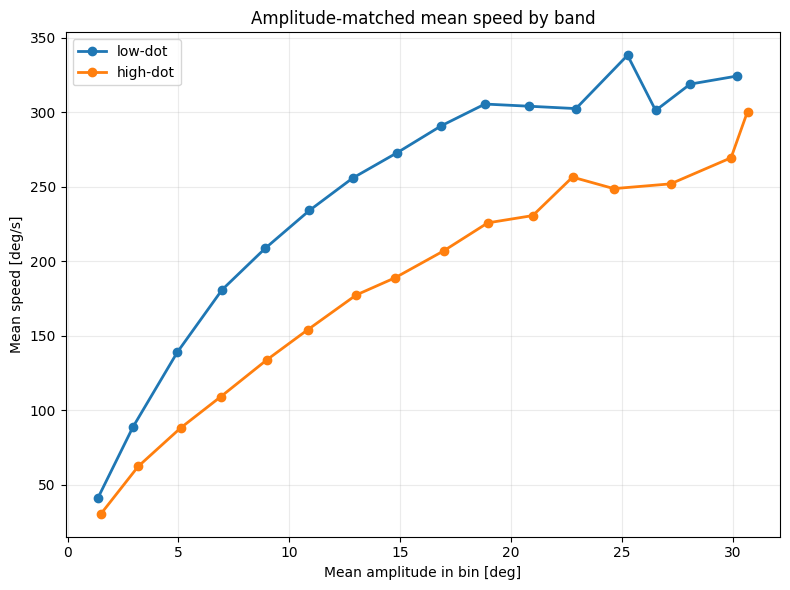

,n,median_amplitude_deg,median_duration_ms,median_mean_speed_amp_duration,mean_mean_speed_amp_duration,median_peak_velocity_csv,median_max_speed_window
band_label,,,,,,,
high-dot,866,7.101626,64.0,112.721345,126.518669,436.543757,436.543757
low-dot,1047,5.674452,41.0,154.223037,162.571882,389.583843,389.583843


In [7]:
# ============================================================
# Speed traces by band_label
#
# TA goal:
#   Write a function plot_speed_traces_by_band(
#       dataframe_raw,
#       dataframe_saccades
#   )
#   that plots speed as a function of time for each saccade,
#   colored by band_label.
#
# In this notebook:
#   dataframe_raw = trace_bank loaded from s189_trace_bank.pkl
#   dataframe_saccades = all_saccades_s189_band.csv
#
# the trace bank contains
# the actual speed-vs-time arrays.
# ============================================================

from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------

SUBJECT_ID = "s189"

OUT_DIR = Path("/content/drive/MyDrive/steer_search_PD/main_sequence_outputs")

SACCADE_BAND_PATH = OUT_DIR / f"all_saccades_{SUBJECT_ID}_band.csv"
TRACE_BANK_PATH = OUT_DIR / f"{SUBJECT_ID}_trace_bank.pkl"

assert SACCADE_BAND_PATH.exists(), f"Missing: {SACCADE_BAND_PATH}"
assert TRACE_BANK_PATH.exists(), f"Missing: {TRACE_BANK_PATH}"

# ------------------------------------------------------------
# 2. Load band-labeled saccades and trace bank
# ------------------------------------------------------------

dataframe_saccades = pd.read_csv(SACCADE_BAND_PATH)

with open(TRACE_BANK_PATH, "rb") as f:
    dataframe_raw = pickle.load(f)

print("Loaded band CSV:", SACCADE_BAND_PATH)
print("Saccade rows:", len(dataframe_saccades))

print("\nLoaded trace bank:", TRACE_BANK_PATH)
print("Trace bank entries:", len(dataframe_raw))

print("\nBand counts:")
print(dataframe_saccades["band_label"].value_counts(dropna=False))

# ------------------------------------------------------------
# 3. Rebuild trace_key so saccades match trace bank
# ------------------------------------------------------------

dataframe_saccades["trace_key_for_bank"] = (
    dataframe_saccades["subject_id"].astype(str) + "|" +
    dataframe_saccades["block_id"].astype(str) + "|" +
    dataframe_saccades["trial"].astype(int).astype(str) + "|" +
    dataframe_saccades["saccade_index"].astype(int).astype(str)
)

n_matching = dataframe_saccades["trace_key_for_bank"].isin(
    dataframe_raw.keys()
).sum()

print("\nTrace keys matching trace bank:", n_matching, "/", len(dataframe_saccades))

if n_matching == 0:
    raise ValueError(
        "No saccade rows matched the trace bank. "
        "Check subject_id, block_id, trial, and saccade_index."
    )

# ------------------------------------------------------------
# 4. Main function requested by TA
# ------------------------------------------------------------

def plot_speed_traces_by_band(
    dataframe_raw,
    dataframe_saccades,
    max_saccades_per_band=None,
    pre_plot_ms=25,
    post_after_stop_ms=25,
    fixed_xlim=(-25, 150),
    fixed_ylim=None,
    plot_individual=True,
    plot_mean=True,
    plot_median=True,
    random_state=42,
    alpha=0.25,
    linewidth=1.0,
):
    """
    Plot speed as a function of time for each saccade,
    colored by band_label.

    Parameters
    ----------
    dataframe_raw : dict
        Here this is the trace_bank loaded from s189_trace_bank.pkl.

        Each trace_bank entry should contain:
            t_rel_ms
            speed_deg_s
            duration_ms_from_time

    dataframe_saccades : pd.DataFrame
        Saccade-level dataframe.

        Must contain:
            band_label
            trace_key_for_bank
            duration_ms
            amplitude_deg
            peak_velocity_deg_s

    max_saccades_per_band : int
        Maximum number of individual traces to plot per band.
        Prevents thousands of curves from making the plot unreadable.

    pre_plot_ms : float
        How many ms before saccade onset to show.

    post_after_stop_ms : float
        How many ms after saccade offset to show.

    fixed_xlim : tuple or None
        x-axis limits. Use (-25, 150) for plots.

    fixed_ylim : tuple or None
        y-axis limits. If None, uses 99.5 percentile to avoid one artifact
        making the plot unreadable.

    plot_individual : bool
        Plot individual speed traces.

    plot_mean : bool
        Plot mean speed trace by band.

    plot_median : bool
        Plot median speed trace by band.

    Returns
    -------
    traces_df : pd.DataFrame
        Long-format dataframe with one row per time sample per saccade.
    """

    trace_bank = dataframe_raw
    sacs = dataframe_saccades.copy()

    required_cols = [
        "band_label",
        "trace_key_for_bank",
        "duration_ms",
        "amplitude_deg",
        "peak_velocity_deg_s",
    ]

    missing = [c for c in required_cols if c not in sacs.columns]
    if missing:
        raise ValueError(f"dataframe_saccades missing columns: {missing}")

    # Keep only labeled saccades with trace-bank entries
    sacs = sacs.dropna(subset=["band_label"]).copy()
    sacs = sacs[sacs["trace_key_for_bank"].isin(trace_bank.keys())].copy()

    if len(sacs) == 0:
        raise ValueError("No labeled saccades have matching trace-bank entries.")

    # Fixed colors so bands are visually meaningful
    color_map = {
        "low-dot": "tab:blue",
        "high-dot": "tab:orange",
    }


    # Sample equal-ish number from each band for readability
    # If max_saccades_per_band=None, use ALL saccades
    # --------------------------------------------------------

    sampled_parts = []

    for label in ["low-dot", "high-dot"]:
        temp = sacs[sacs["band_label"] == label].copy()

        if max_saccades_per_band is not None:
            if len(temp) > max_saccades_per_band:
                temp = temp.sample(
                    n=max_saccades_per_band,
                    random_state=random_state,
                )

        sampled_parts.append(temp)

    sacs_plot = pd.concat(sampled_parts, axis=0).sort_index()



    # --------------------------------------------------------
    # Build long dataframe of speed traces
    # --------------------------------------------------------

    trace_rows = []

    skipped = []

    for row_idx, row in sacs_plot.iterrows():

        key = row["trace_key_for_bank"]
        band_label = row["band_label"]

        tr = trace_bank[key]

        if "t_rel_ms" not in tr or "speed_deg_s" not in tr:
            skipped.append((key, "missing t_rel_ms or speed_deg_s"))
            continue

        t_rel = np.asarray(tr["t_rel_ms"], dtype=float)
        speed = np.asarray(tr["speed_deg_s"], dtype=float)

        if len(t_rel) != len(speed):
            skipped.append((key, "t_rel_ms and speed_deg_s length mismatch"))
            continue

        # Use duration from trace bank if possible
        if "duration_ms_from_time" in tr and np.isfinite(tr["duration_ms_from_time"]):
            duration_ms = float(tr["duration_ms_from_time"])
        else:
            duration_ms = float(row["duration_ms"])

        # Keep only around the detected saccade.
        # This removes later unrelated saccades from the post-window.
        keep = (
            (t_rel >= -pre_plot_ms)
            & (t_rel <= duration_ms + post_after_stop_ms)
        )

        t_keep = t_rel[keep]
        speed_keep = speed[keep]

        if len(t_keep) == 0:
            skipped.append((key, "empty after trimming"))
            continue

        for t, s in zip(t_keep, speed_keep):
            trace_rows.append({
                "saccade_row": row_idx,
                "trace_key": key,
                "band_label": band_label,
                "rel_time_ms": t,
                "speed_deg_s": s,
                "duration_ms": duration_ms,
                "amplitude_deg": row["amplitude_deg"],
                "peak_velocity_deg_s": row["peak_velocity_deg_s"],
                "block_id": row.get("block_id", np.nan),
                "trial": row.get("trial", np.nan),
                "image": row.get("image", np.nan),
                "saccade_index": row.get("saccade_index", np.nan),
            })

    traces_df = pd.DataFrame(trace_rows)

    if traces_df.empty:
        raise ValueError("No traces were extracted.")

    print("\nExtracted trace samples:", traces_df.shape)
    print("Skipped traces:", len(skipped))

    if len(skipped) > 0:
        print("First skipped examples:")
        print(skipped[:5])

    # --------------------------------------------------------
    # Helper for y-limits
    # --------------------------------------------------------

    if fixed_ylim is None:
        ymax = np.nanpercentile(traces_df["speed_deg_s"], 99.5)
        fixed_ylim_use = (-20, ymax * 1.1)
    else:
        fixed_ylim_use = fixed_ylim

    # --------------------------------------------------------
    # Plot 1: individual traces
    # --------------------------------------------------------

    if plot_individual:

        fig, ax = plt.subplots(figsize=(14, 5))

        for label in ["low-dot", "high-dot"]:
            temp = traces_df[traces_df["band_label"] == label]

            for _, one_trace in temp.groupby("trace_key"):
                ax.plot(
                    one_trace["rel_time_ms"],
                    one_trace["speed_deg_s"],
                    color=color_map[label],
                    alpha=alpha,
                    linewidth=linewidth,
                )

        # Clean legend handles
        ax.plot([], [], color=color_map["low-dot"], linewidth=2, label="low-dot")
        ax.plot([], [], color=color_map["high-dot"], linewidth=2, label="high-dot")

        ax.axvline(
            0,
            color="green",
            linestyle="--",
            linewidth=1.8,
            label="start",
        )

        ax.set_xlabel("Time from saccade onset [ms]")
        ax.set_ylabel("speed [deg/s]")
        ax.set_title("Individual speed traces by band")

        if fixed_xlim is not None:
            ax.set_xlim(fixed_xlim)

        ax.set_ylim(fixed_ylim_use)
        ax.legend(loc="upper right")
        ax.grid(alpha=0.25)

        plt.tight_layout()
        plt.show()

    # --------------------------------------------------------
    # Prepare binned traces for mean/median
    # --------------------------------------------------------

    traces_df["_rel_time_bin_ms"] = np.round(
        traces_df["rel_time_ms"]
    ).astype(int)

    # --------------------------------------------------------
    # Plot 2: mean speed trace by band
    # --------------------------------------------------------

    if plot_mean:

        fig, ax = plt.subplots(figsize=(14, 5))

        for label in ["low-dot", "high-dot"]:

            temp = traces_df[traces_df["band_label"] == label].copy()

            mean_trace = (
                temp
                .groupby("_rel_time_bin_ms")["speed_deg_s"]
                .agg(["mean", "sem", "count"])
                .reset_index()
            )

            ax.plot(
                mean_trace["_rel_time_bin_ms"],
                mean_trace["mean"],
                color=color_map[label],
                linewidth=3,
                label=f"{label} mean",
            )

            ax.fill_between(
                mean_trace["_rel_time_bin_ms"],
                mean_trace["mean"] - mean_trace["sem"],
                mean_trace["mean"] + mean_trace["sem"],
                color=color_map[label],
                alpha=0.20,
            )

        ax.axvline(
            0,
            color="green",
            linestyle="--",
            linewidth=1.8,
            label="start",
        )

        ax.set_xlabel("Time from saccade onset [ms]")
        ax.set_ylabel("speed [deg/s]")
        ax.set_title("Mean speed trace by band")

        if fixed_xlim is not None:
            ax.set_xlim(fixed_xlim)

        ax.set_ylim(fixed_ylim_use)
        ax.legend(loc="upper right")
        ax.grid(alpha=0.25)

        plt.tight_layout()
        plt.show()

    # --------------------------------------------------------
    # Plot 3: median speed trace by band
    # This is useful because mean can be distorted by huge artifacts.
    # --------------------------------------------------------

    if plot_median:

        fig, ax = plt.subplots(figsize=(14, 5))

        for label in ["low-dot", "high-dot"]:

            temp = traces_df[traces_df["band_label"] == label].copy()

            median_trace = (
                temp
                .groupby("_rel_time_bin_ms")["speed_deg_s"]
                .agg(
                    median="median",
                    q25=lambda x: np.nanpercentile(x, 25),
                    q75=lambda x: np.nanpercentile(x, 75),
                    count="count",
                )
                .reset_index()
            )

            ax.plot(
                median_trace["_rel_time_bin_ms"],
                median_trace["median"],
                color=color_map[label],
                linewidth=3,
                label=f"{label} median",
            )

            ax.fill_between(
                median_trace["_rel_time_bin_ms"],
                median_trace["q25"],
                median_trace["q75"],
                color=color_map[label],
                alpha=0.20,
            )

        ax.axvline(
            0,
            color="green",
            linestyle="--",
            linewidth=1.8,
            label="start",
        )

        ax.set_xlabel("Time from saccade onset [ms]")
        ax.set_ylabel("speed [deg/s]")
        ax.set_title("Median speed trace by band")

        if fixed_xlim is not None:
            ax.set_xlim(fixed_xlim)

        ax.set_ylim(fixed_ylim_use)
        ax.legend(loc="upper right")
        ax.grid(alpha=0.25)

        plt.tight_layout()
        plt.show()

    # --------------------------------------------------------
    # Numeric summary useful for TA
    # --------------------------------------------------------

    trace_summary = (
        traces_df
        .groupby(["trace_key", "band_label"])
        .agg(
            max_speed_window_deg_s=("speed_deg_s", "max"),
            duration_ms=("duration_ms", "first"),
            amplitude_deg=("amplitude_deg", "first"),
            peak_velocity_deg_s=("peak_velocity_deg_s", "first"),
        )
        .reset_index()
    )

    print("\nPer-trace summary by band:")
    display(
        trace_summary
        .groupby("band_label")
        .agg(
            n=("trace_key", "count"),
            median_duration_ms=("duration_ms", "median"),
            median_amplitude_deg=("amplitude_deg", "median"),
            median_peak_velocity_csv=("peak_velocity_deg_s", "median"),
            median_max_speed_window=("max_speed_window_deg_s", "median"),
            mean_max_speed_window=("max_speed_window_deg_s", "mean"),
        )
    )

    return traces_df, trace_summary


# ------------------------------------------------------------
# 5. Run the TA-requested function
# ------------------------------------------------------------

traces_df, trace_summary = plot_speed_traces_by_band(
    dataframe_raw=dataframe_raw,
    dataframe_saccades=dataframe_saccades,
    max_saccades_per_band=None,
    pre_plot_ms=25,
    post_after_stop_ms=25,
    fixed_xlim=(-25, 150),
    fixed_ylim=None,
    plot_individual=True,
    plot_mean=True,
    plot_median=True,
    random_state=42,
    alpha=0.25,
    linewidth=1.0,
)

print("\nReturned traces_df:")
print(traces_df.shape)
display(traces_df.head())

print("\nReturned trace_summary:")
print(trace_summary.shape)
display(trace_summary.head())

df_check = df_band.dropna(subset=["band_label"]).copy()

df_check["mean_speed_deg_s"] = (
    df_check["amplitude_deg"] / (df_check["duration_ms"] / 1000.0)
)

df_check["amp_bin"] = pd.cut(
    df_check["amplitude_deg"],
    bins=np.arange(0, df_check["amplitude_deg"].max() + 2, 2)
)

bin_summary = (
    df_check
    .groupby(["amp_bin", "band_label"], observed=True)
    .agg(
        n=("band_label", "size"),
        mean_amp=("amplitude_deg", "mean"),
        mean_duration=("duration_ms", "mean"),
        mean_speed=("mean_speed_deg_s", "mean"),
    )
    .reset_index()
)

display(bin_summary)

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Graph 1: Mean speed vs amplitude bin
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

for band in ["low-dot", "high-dot"]:
    d = bin_summary[bin_summary["band_label"] == band].copy()

    plt.plot(
        d["mean_amp"],
        d["mean_speed"],
        marker="o",
        linewidth=2,
        label=band
    )

plt.xlabel("Mean amplitude in bin [deg]")
plt.ylabel("Mean speed [deg/s]")
plt.title("Amplitude-matched mean speed by band")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

trace_summary["mean_speed_amp_duration_deg_s"] = (
    trace_summary["amplitude_deg"] / (trace_summary["duration_ms"] / 1000.0)
)

display(
    trace_summary
    .groupby("band_label")
    .agg(
        n=("trace_key", "count"),
        median_amplitude_deg=("amplitude_deg", "median"),
        median_duration_ms=("duration_ms", "median"),
        median_mean_speed_amp_duration=("mean_speed_amp_duration_deg_s", "median"),
        mean_mean_speed_amp_duration=("mean_speed_amp_duration_deg_s", "mean"),
        median_peak_velocity_csv=("peak_velocity_deg_s", "median"),
        median_max_speed_window=("max_speed_window_deg_s", "median"),
    )
)

Loaded saccades: (1913, 35)
Loaded trace bank entries: 1913

Trace matches:
has_trace
True    1913
Name: count, dtype: int64

Top candidate problematic blocks:


band_label,block_id,n_high_dot,n_low_dot,n_total,high_dot_fraction,mix_score,median_duration_low,median_duration_high,duration_gap_high_minus_low,median_amp_low,median_amp_high,amp_gap_high_minus_low,median_peak_low,median_peak_high,peak_gap_high_minus_low,problem_score
0,250807_170121,279,306,585,0.476923,0.953846,41.0,66.0,25.0,5.931683,8.740632,2.808949,395.711060,466.741857,71.030797,13.467692
1,250807_171455,233,255,488,0.477459,0.954918,40.0,64.0,24.0,6.182796,6.944532,0.761735,397.872793,435.827281,37.954488,12.930033
2,250807_172307,193,218,411,0.469586,0.939173,42.0,64.0,22.0,6.117570,7.030459,0.912888,390.353343,430.808559,40.455216,11.966672
3,250807_172925,194,235,429,0.452214,0.904429,41.0,63.0,22.0,5.474536,6.797946,1.323410,373.208309,425.890134,52.681826,11.468629



Selected problematic block:
250807_170121


band_label,block_id,n_high_dot,n_low_dot,n_total,high_dot_fraction,mix_score,median_duration_low,median_duration_high,duration_gap_high_minus_low,median_amp_low,median_amp_high,amp_gap_high_minus_low,median_peak_low,median_peak_high,peak_gap_high_minus_low,problem_score
0,250807_170121,279,306,585,0.476923,0.953846,41.0,66.0,25.0,5.931683,8.740632,2.808949,395.71106,466.741857,71.030797,13.467692



Plotting block: 250807_170121
Saccades in block:
band_label
low-dot     306
high-dot    279
Name: count, dtype: int64


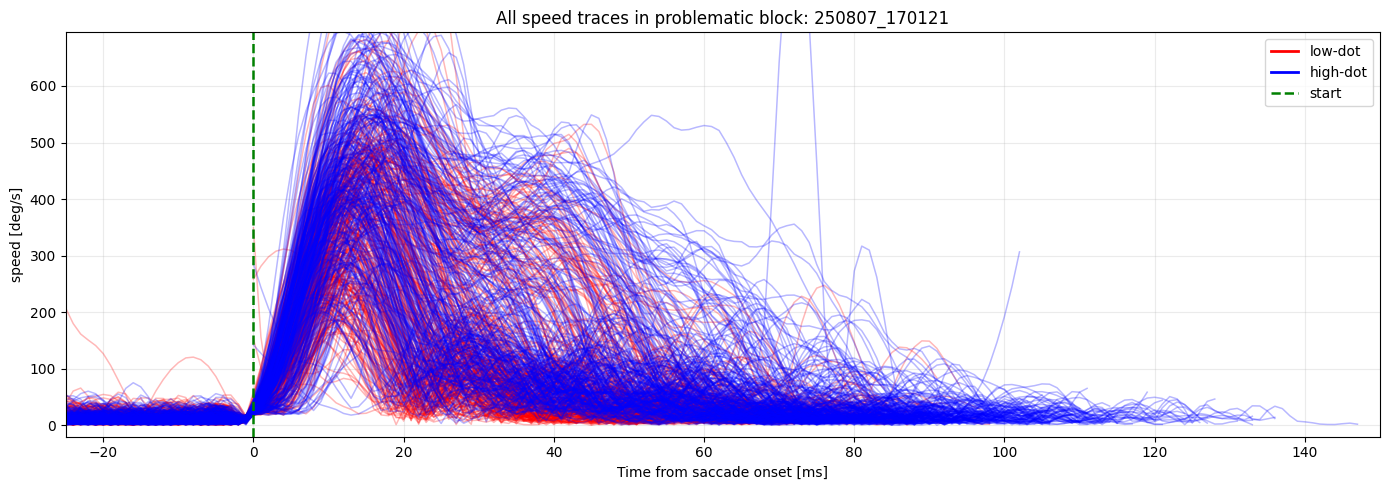


Returned block_traces_df:
(61446, 12)


,saccade_row,trace_key,band_label,rel_time_ms,speed_deg_s,duration_ms,amplitude_deg,peak_velocity_deg_s,block_id,trial,image,saccade_index
0,0,s189|250807_170121|1|0,low-dot,-25.0,9.062720,39.0,3.539195,343.028372,250807_170121,1,044.jpg,0
1,0,s189|250807_170121|1|0,low-dot,-24.0,15.826920,39.0,3.539195,343.028372,250807_170121,1,044.jpg,0
2,0,s189|250807_170121|1|0,low-dot,-23.0,18.298985,39.0,3.539195,343.028372,250807_170121,1,044.jpg,0
3,0,s189|250807_170121|1|0,low-dot,-22.0,18.307383,39.0,3.539195,343.028372,250807_170121,1,044.jpg,0
4,0,s189|250807_170121|1|0,low-dot,-21.0,17.837236,39.0,3.539195,343.028372,250807_170121,1,044.jpg,0



Plotting low-dot
Number of saccades: 306
Number of time samples: 28282


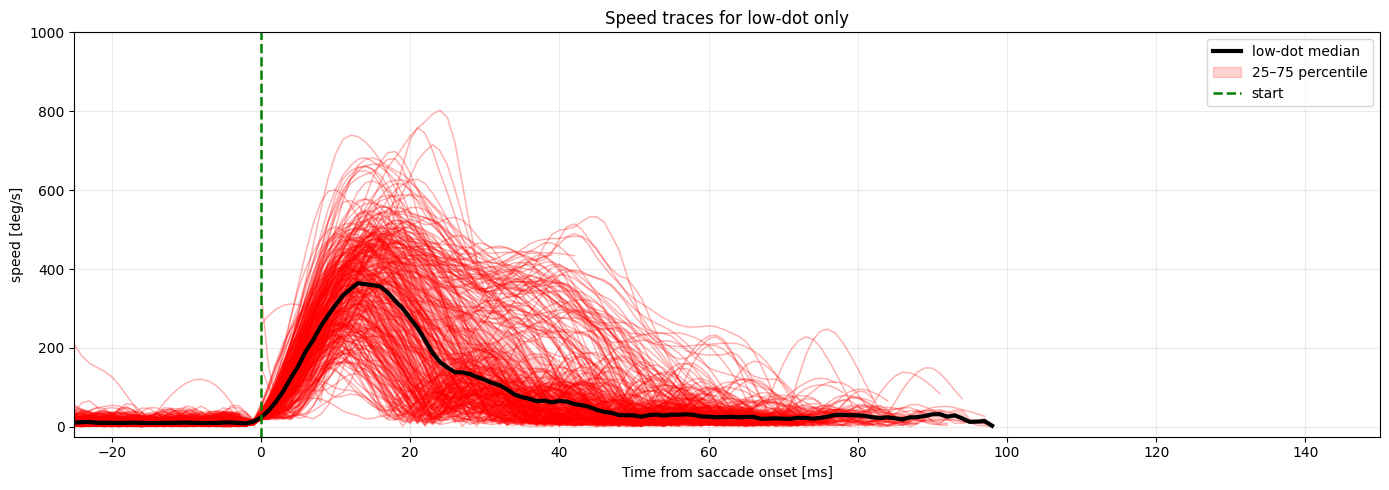


Plotting high-dot
Number of saccades: 279
Number of time samples: 33164


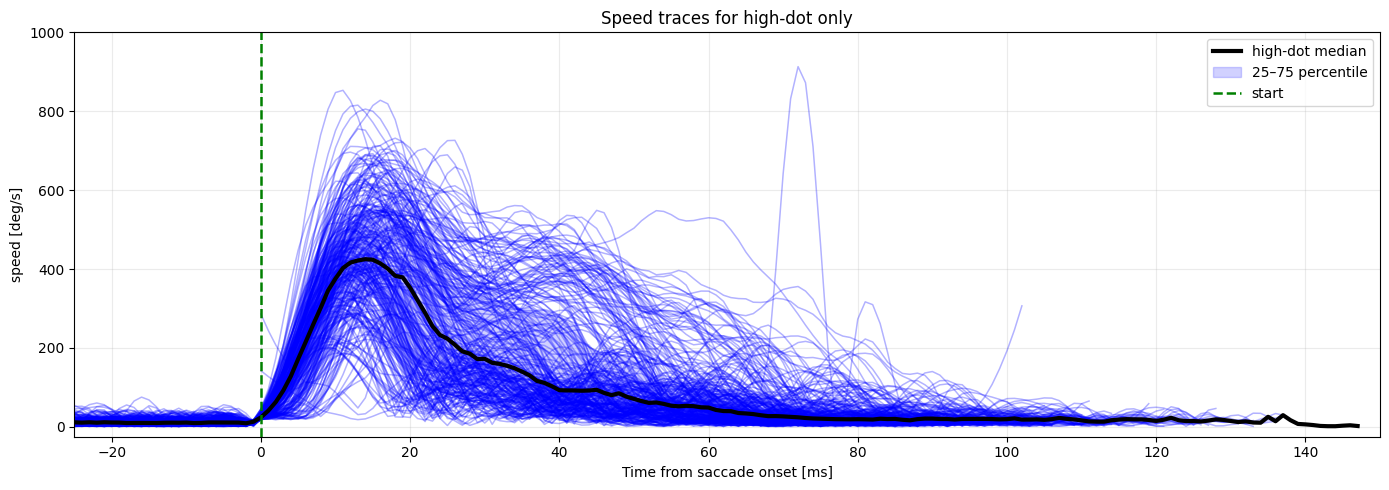

In [14]:
# ============================================================
# Pick one problematic block and plot every speed trace in it
#
# Problematic block = block where:
#   - enough saccades exist
#   - both low-dot and high-dot exist
#   - high-dot fraction is substantial
#   - high-dot duration is longer than low-dot duration
#
# Then plot all speed curves in that block:
#   low-dot  = red
#   high-dot = blue
# ============================================================

from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Load band-labeled saccades and trace bank
# ------------------------------------------------------------

SUBJECT_ID = "s189"

OUT_DIR = Path("/content/drive/MyDrive/steer_search_PD/main_sequence_outputs")

SACCADE_BAND_PATH = OUT_DIR / f"all_saccades_{SUBJECT_ID}_band.csv"
TRACE_BANK_PATH = OUT_DIR / f"{SUBJECT_ID}_trace_bank.pkl"

assert SACCADE_BAND_PATH.exists(), f"Missing: {SACCADE_BAND_PATH}"
assert TRACE_BANK_PATH.exists(), f"Missing: {TRACE_BANK_PATH}"

dataframe_saccades = pd.read_csv(SACCADE_BAND_PATH)

with open(TRACE_BANK_PATH, "rb") as f:
    dataframe_raw = pickle.load(f)

print("Loaded saccades:", dataframe_saccades.shape)
print("Loaded trace bank entries:", len(dataframe_raw))

# ------------------------------------------------------------
# 2. Rebuild trace_key to match trace bank
# ------------------------------------------------------------

dataframe_saccades["trace_key_for_bank"] = (
    dataframe_saccades["subject_id"].astype(str) + "|" +
    dataframe_saccades["block_id"].astype(str) + "|" +
    dataframe_saccades["trial"].astype(int).astype(str) + "|" +
    dataframe_saccades["saccade_index"].astype(int).astype(str)
)

dataframe_saccades["has_trace"] = dataframe_saccades["trace_key_for_bank"].isin(
    dataframe_raw.keys()
)

print("\nTrace matches:")
print(dataframe_saccades["has_trace"].value_counts(dropna=False))

# ------------------------------------------------------------
# 3. Summarize each block
# ------------------------------------------------------------

def summarize_blocks_for_band_problem(dataframe_saccades):
    """
    Creates a block-level summary to choose a problematic block.

    Good block for inspection:
        - many total saccades
        - both low-dot and high-dot present
        - high-dot fraction is substantial
        - high-dot duration > low-dot duration
    """

    df = dataframe_saccades.copy()
    df = df.dropna(subset=["band_label"]).copy()

    # Keep only rows with trace bank entries, because we need to plot speed curves
    df = df[df["has_trace"]].copy()

    # Counts by block and band
    counts = (
        df
        .groupby(["block_id", "band_label"])
        .size()
        .unstack(fill_value=0)
    )

    for col in ["low-dot", "high-dot"]:
        if col not in counts.columns:
            counts[col] = 0

    counts = counts.rename(
        columns={
            "low-dot": "n_low_dot",
            "high-dot": "n_high_dot",
        }
    )

    counts["n_total"] = counts["n_low_dot"] + counts["n_high_dot"]
    counts["high_dot_fraction"] = counts["n_high_dot"] / counts["n_total"]

    # Mix score is high when both bands are represented
    counts["mix_score"] = (
        2 * np.minimum(counts["n_low_dot"], counts["n_high_dot"])
        / counts["n_total"]
    )

    # Median duration by block and band
    dur = (
        df
        .groupby(["block_id", "band_label"])["duration_ms"]
        .median()
        .unstack()
    )

    amp = (
        df
        .groupby(["block_id", "band_label"])["amplitude_deg"]
        .median()
        .unstack()
    )

    peak = (
        df
        .groupby(["block_id", "band_label"])["peak_velocity_deg_s"]
        .median()
        .unstack()
    )

    summary = counts.copy()

    summary["median_duration_low"] = dur.get("low-dot", np.nan)
    summary["median_duration_high"] = dur.get("high-dot", np.nan)
    summary["duration_gap_high_minus_low"] = (
        summary["median_duration_high"] - summary["median_duration_low"]
    )

    summary["median_amp_low"] = amp.get("low-dot", np.nan)
    summary["median_amp_high"] = amp.get("high-dot", np.nan)
    summary["amp_gap_high_minus_low"] = (
        summary["median_amp_high"] - summary["median_amp_low"]
    )

    summary["median_peak_low"] = peak.get("low-dot", np.nan)
    summary["median_peak_high"] = peak.get("high-dot", np.nan)
    summary["peak_gap_high_minus_low"] = (
        summary["median_peak_high"] - summary["median_peak_low"]
    )

    # Main ranking score:
    # prefer blocks with both bands, many saccades, and larger duration gap
    duration_gap_positive = summary["duration_gap_high_minus_low"].clip(lower=0)

    summary["problem_score"] = (
        np.log1p(summary["n_total"])
        * summary["mix_score"]
        * (1 + summary["high_dot_fraction"])
        * (1 + duration_gap_positive / 50.0)
    )

    summary = summary.reset_index()

    return summary


block_summary = summarize_blocks_for_band_problem(dataframe_saccades)

# ------------------------------------------------------------
# 4. Show candidate problematic blocks
# ------------------------------------------------------------

# Avoid tiny blocks
MIN_TOTAL = 20
MIN_LOW = 5
MIN_HIGH = 5

candidate_blocks = block_summary[
    (block_summary["n_total"] >= MIN_TOTAL)
    & (block_summary["n_low_dot"] >= MIN_LOW)
    & (block_summary["n_high_dot"] >= MIN_HIGH)
].copy()

candidate_blocks = candidate_blocks.sort_values(
    "problem_score",
    ascending=False,
)

print("\nTop candidate problematic blocks:")
display(candidate_blocks.head(15))

if len(candidate_blocks) == 0:
    raise ValueError(
        "No block passed the minimum thresholds. "
        "Try lowering MIN_TOTAL, MIN_LOW, or MIN_HIGH."
    )

SELECTED_BLOCK_ID = candidate_blocks.iloc[0]["block_id"]

print("\nSelected problematic block:")
print(SELECTED_BLOCK_ID)

display(
    candidate_blocks[
        candidate_blocks["block_id"] == SELECTED_BLOCK_ID
    ]
)

# ------------------------------------------------------------
# 5. Plot all speed curves in selected block
# ------------------------------------------------------------

def plot_speed_traces_for_one_block(
    dataframe_raw,
    dataframe_saccades,
    block_id,
    pre_plot_ms=25,
    post_after_stop_ms=25,
    fixed_xlim=(-25, 150),
    fixed_ylim=None,
    alpha=0.28,
    linewidth=1.1,
):
    """
    Plot every speed curve for one block.

    low-dot  = red
    high-dot = blue

    dataframe_raw:
        trace bank dictionary loaded from s189_trace_bank.pkl

    dataframe_saccades:
        all_saccades_s189_band.csv dataframe with trace_key_for_bank
    """

    trace_bank = dataframe_raw

    df = dataframe_saccades.copy()
    df = df.dropna(subset=["band_label"]).copy()
    df = df[df["has_trace"]].copy()

    block_df = df[df["block_id"].astype(str) == str(block_id)].copy()

    if len(block_df) == 0:
        raise ValueError(f"No saccades found for block_id={block_id}")

    print("\nPlotting block:", block_id)
    print("Saccades in block:")
    print(block_df["band_label"].value_counts())

    color_map = {
        "low-dot": "red",
        "high-dot": "blue",
    }

    trace_rows = []

    for row_idx, row in block_df.iterrows():

        key = row["trace_key_for_bank"]
        tr = trace_bank[key]

        t_rel = np.asarray(tr["t_rel_ms"], dtype=float)
        speed = np.asarray(tr["speed_deg_s"], dtype=float)

        if len(t_rel) != len(speed):
            print("Skipping mismatched trace:", key)
            continue

        if "duration_ms_from_time" in tr and np.isfinite(tr["duration_ms_from_time"]):
            duration_ms = float(tr["duration_ms_from_time"])
        else:
            duration_ms = float(row["duration_ms"])

        keep = (
            (t_rel >= -pre_plot_ms)
            & (t_rel <= duration_ms + post_after_stop_ms)
        )

        t_keep = t_rel[keep]
        speed_keep = speed[keep]

        for t, s in zip(t_keep, speed_keep):
            trace_rows.append({
                "saccade_row": row_idx,
                "trace_key": key,
                "band_label": row["band_label"],
                "rel_time_ms": t,
                "speed_deg_s": s,
                "duration_ms": duration_ms,
                "amplitude_deg": row["amplitude_deg"],
                "peak_velocity_deg_s": row["peak_velocity_deg_s"],
                "block_id": row["block_id"],
                "trial": row["trial"],
                "image": row["image"],
                "saccade_index": row["saccade_index"],
            })

    block_traces_df = pd.DataFrame(trace_rows)

    if block_traces_df.empty:
        raise ValueError("No traces extracted for this block.")

    fig, ax = plt.subplots(figsize=(14, 5))

    for label in ["low-dot", "high-dot"]:
        temp = block_traces_df[block_traces_df["band_label"] == label]

        for _, one_trace in temp.groupby("trace_key"):
            ax.plot(
                one_trace["rel_time_ms"],
                one_trace["speed_deg_s"],
                color=color_map[label],
                alpha=alpha,
                linewidth=linewidth,
            )

    # Clean legend
    ax.plot([], [], color="red", linewidth=2, label="low-dot")
    ax.plot([], [], color="blue", linewidth=2, label="high-dot")

    ax.axvline(
        0,
        color="green",
        linestyle="--",
        linewidth=1.8,
        label="start",
    )

    ax.set_xlabel("Time from saccade onset [ms]")
    ax.set_ylabel("speed [deg/s]")
    ax.set_title(f"All speed traces in problematic block: {block_id}")

    if fixed_xlim is not None:
        ax.set_xlim(fixed_xlim)

    if fixed_ylim is None:
        ymax = np.nanpercentile(block_traces_df["speed_deg_s"], 99.5)
        ax.set_ylim(-20, ymax * 1.1)
    else:
        ax.set_ylim(fixed_ylim)

    ax.legend(loc="upper right")
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    return block_traces_df


block_traces_df = plot_speed_traces_for_one_block(
    dataframe_raw=dataframe_raw,
    dataframe_saccades=dataframe_saccades,
    block_id=SELECTED_BLOCK_ID,
    pre_plot_ms=25,
    post_after_stop_ms=25,
    fixed_xlim=(-25, 150),
    fixed_ylim=None,
    alpha=0.28,
    linewidth=1.1,
)

print("\nReturned block_traces_df:")
print(block_traces_df.shape)
display(block_traces_df.head())

# ============================================================
# Separate speed-time plots:
#   1. all low-dot traces only, in red
#   2. all high-dot traces only, in blue
#
# Requires:
#   block_traces_df
# from the previous problematic-block plotting cell.
# ============================================================

def plot_one_band_speed_traces(
    block_traces_df,
    band_label,
    color,
    fixed_xlim=(-25, 150),
    fixed_ylim=None,
    alpha=0.30,
    linewidth=1.1,
    show_median=True,
):
    """
    Plot speed-vs-time curves for only one band.

    Example:
        band_label="low-dot", color="red"
        band_label="high-dot", color="blue"
    """

    df = block_traces_df[
        block_traces_df["band_label"] == band_label
    ].copy()

    if df.empty:
        raise ValueError(f"No traces found for band_label={band_label}")

    print(f"\nPlotting {band_label}")
    print("Number of saccades:", df["trace_key"].nunique())
    print("Number of time samples:", len(df))

    fig, ax = plt.subplots(figsize=(14, 5))

    # --------------------------------------------------------
    # Individual traces
    # --------------------------------------------------------

    for _, one_trace in df.groupby("trace_key"):
        ax.plot(
            one_trace["rel_time_ms"],
            one_trace["speed_deg_s"],
            color=color,
            alpha=alpha,
            linewidth=linewidth,
        )

    # --------------------------------------------------------
    # Optional median trace
    # --------------------------------------------------------

    if show_median:
        df["_rel_time_bin_ms"] = np.round(df["rel_time_ms"]).astype(int)

        median_trace = (
            df
            .groupby("_rel_time_bin_ms")["speed_deg_s"]
            .agg(
                median="median",
                q25=lambda x: np.nanpercentile(x, 25),
                q75=lambda x: np.nanpercentile(x, 75),
                count="count",
            )
            .reset_index()
        )

        ax.plot(
            median_trace["_rel_time_bin_ms"],
            median_trace["median"],
            color="black",
            linewidth=3,
            label=f"{band_label} median",
        )

        ax.fill_between(
            median_trace["_rel_time_bin_ms"],
            median_trace["q25"],
            median_trace["q75"],
            color=color,
            alpha=0.18,
            label="25–75 percentile",
        )

    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------

    ax.axvline(
        0,
        color="green",
        linestyle="--",
        linewidth=1.8,
        label="start",
    )

    ax.set_xlabel("Time from saccade onset [ms]")
    ax.set_ylabel("speed [deg/s]")
    ax.set_title(f"Speed traces for {band_label} only")

    if fixed_xlim is not None:
        ax.set_xlim(fixed_xlim)

    if fixed_ylim is None:
        ymax = np.nanpercentile(df["speed_deg_s"], 99.5)
        ax.set_ylim(-20, ymax * 1.1)
    else:
        ax.set_ylim(fixed_ylim)

    ax.legend(loc="upper right")
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    return df


# ------------------------------------------------------------
# Plot all red dots only = low-dot
# ------------------------------------------------------------

low_dot_traces_df = plot_one_band_speed_traces(
    block_traces_df=block_traces_df,
    band_label="low-dot",
    color="red",
    fixed_xlim=(-25, 150),
    # fixed_ylim=None,
    fixed_ylim=(-25, 1000),
    alpha=0.30,
    linewidth=1.1,
    show_median=True,
)

# ------------------------------------------------------------
# Plot all blue dots only = high-dot
# ------------------------------------------------------------

high_dot_traces_df = plot_one_band_speed_traces(
    block_traces_df=block_traces_df,
    band_label="high-dot",
    color="blue",
    fixed_xlim=(-25, 150),
    # fixed_ylim=None,
    fixed_ylim=(-25, 1000),
    alpha=0.30,
    linewidth=1.1,
    show_median=True,
)

In [15]:
# ============================================================
# Inspect format / columns / fields in s189_trace_bank.pkl
# ============================================================

from pathlib import Path
import pickle
import numpy as np
import pandas as pd

SUBJECT_ID = "s189"

OUT_DIR = Path("/content/drive/MyDrive/steer_search_PD/main_sequence_outputs")
TRACE_BANK_PATH = OUT_DIR / f"{SUBJECT_ID}_trace_bank.pkl"

assert TRACE_BANK_PATH.exists(), f"Missing: {TRACE_BANK_PATH}"

with open(TRACE_BANK_PATH, "rb") as f:
    trace_bank = pickle.load(f)

print("Loaded:", TRACE_BANK_PATH)
print("Object type:", type(trace_bank))
print("Number of trace entries:", len(trace_bank))

# ------------------------------------------------------------
# Print first few trace keys
# ------------------------------------------------------------

keys = list(trace_bank.keys())

print("\nFirst 10 trace keys:")
for k in keys[:10]:
    print(k)

# ------------------------------------------------------------
# Inspect one trace entry
# ------------------------------------------------------------

first_key = keys[0]
trace = trace_bank[first_key]

print("\nExample trace key:")
print(first_key)

print("\nExample trace object type:")
print(type(trace))

print("\nFields inside one trace:")
for field in trace.keys():
    value = trace[field]

    if isinstance(value, np.ndarray):
        print(
            f"{field:30s} | ndarray | shape={value.shape} | dtype={value.dtype}"
        )
    elif isinstance(value, list):
        print(
            f"{field:30s} | list    | len={len(value)}"
        )
    else:
        print(
            f"{field:30s} | {type(value).__name__} | value={value}"
        )

# ------------------------------------------------------------
# Convert scalar metadata from all traces into a dataframe
# ------------------------------------------------------------

rows = []

for key, tr in trace_bank.items():
    row = {"trace_key": key}

    for field, value in tr.items():
        # Keep scalar values only
        if isinstance(value, np.ndarray):
            row[field + "_shape"] = value.shape
            row[field + "_len"] = len(value)
        elif isinstance(value, list):
            row[field + "_len"] = len(value)
        else:
            row[field] = value

    rows.append(row)

trace_meta_df = pd.DataFrame(rows)

print("\nTrace metadata dataframe shape:")
print(trace_meta_df.shape)

print("\nTrace metadata columns:")
print(trace_meta_df.columns.tolist())

display(trace_meta_df.head())

# ------------------------------------------------------------
# Specifically check x/y/speed/time fields
# ------------------------------------------------------------

important_fields = [
    "t_rel_ms",
    "x_deg",
    "y_deg",
    "speed_deg_s",
    "progress_deg",
    "orthogonal_deg",
    "is_blink_sample",
    "valid_after_blink",
]

print("\nImportant field availability:")
for field in important_fields:
    present_count = sum(field in tr for tr in trace_bank.values())
    print(f"{field:25s}: {present_count}/{len(trace_bank)} traces")

# ------------------------------------------------------------
# Show first few samples from one trace
# ------------------------------------------------------------

sample_fields = ["t_rel_ms", "x_deg", "y_deg", "speed_deg_s"]

if all(field in trace for field in sample_fields):
    one_trace_df = pd.DataFrame({
        "t_rel_ms": trace["t_rel_ms"],
        "x_deg": trace["x_deg"],
        "y_deg": trace["y_deg"],
        "speed_deg_s": trace["speed_deg_s"],
    })

    print("\nFirst trace sample-level dataframe:")
    print(one_trace_df.shape)
    display(one_trace_df.head(20))
else:
    print("\nCould not build sample dataframe because some fields are missing.")

Loaded: /content/drive/MyDrive/steer_search_PD/main_sequence_outputs/s189_trace_bank.pkl
Object type: <class 'dict'>
Number of trace entries: 1913

First 10 trace keys:
s189|250807_170121|1|0
s189|250807_170121|1|1
s189|250807_170121|1|2
s189|250807_170121|1|3
s189|250807_170121|1|4
s189|250807_170121|1|5
s189|250807_170121|1|6
s189|250807_170121|1|7
s189|250807_170121|1|8
s189|250807_170121|1|9

Example trace key:
s189|250807_170121|1|0

Example trace object type:
<class 'dict'>

Fields inside one trace:
trace_key                      | str | value=s189|250807_170121|1|0
subject_id                     | str | value=s189
group                          | str | value=Control
block_id                       | str | value=250807_170121
trial                          | int | value=1
image                          | str | value=044.jpg
stim_id                        | str | value=250807_170121_044.jpg
saccade_index                  | int | value=0
start_idx                      | int | value=

,trace_key,subject_id,group,block_id,trial,image,stim_id,saccade_index,start_idx,stop_idx,...,speed_deg_s_shape,speed_deg_s_len,progress_deg_shape,progress_deg_len,orthogonal_deg_shape,orthogonal_deg_len,is_blink_sample_shape,is_blink_sample_len,valid_after_blink_shape,valid_after_blink_len
0,s189|250807_170121|1|0,s189,Control,250807_170121,1,044.jpg,250807_170121_044.jpg,0,232,271,...,"(290,)",290,"(290,)",290,"(290,)",290,"(290,)",290,"(290,)",290
1,s189|250807_170121|1|1,s189,Control,250807_170121,1,044.jpg,250807_170121_044.jpg,1,496,563,...,"(318,)",318,"(318,)",318,"(318,)",318,"(318,)",318,"(318,)",318
2,s189|250807_170121|1|2,s189,Control,250807_170121,1,044.jpg,250807_170121_044.jpg,2,648,694,...,"(297,)",297,"(297,)",297,"(297,)",297,"(297,)",297,"(297,)",297
3,s189|250807_170121|1|3,s189,Control,250807_170121,1,044.jpg,250807_170121_044.jpg,3,1024,1056,...,"(283,)",283,"(283,)",283,"(283,)",283,"(283,)",283,"(283,)",283
4,s189|250807_170121|1|4,s189,Control,250807_170121,1,044.jpg,250807_170121_044.jpg,4,1182,1249,...,"(318,)",318,"(318,)",318,"(318,)",318,"(318,)",318,"(318,)",318



Important field availability:
t_rel_ms                 : 1913/1913 traces
x_deg                    : 1913/1913 traces
y_deg                    : 1913/1913 traces
speed_deg_s              : 1913/1913 traces
progress_deg             : 1913/1913 traces
orthogonal_deg           : 1913/1913 traces
is_blink_sample          : 1913/1913 traces
valid_after_blink        : 1913/1913 traces

First trace sample-level dataframe:
(290, 4)


,t_rel_ms,x_deg,y_deg,speed_deg_s
0,-100.0,1.083229,0.064142,7.174695
1,-99.0,1.078880,0.063823,6.784986
2,-98.0,1.078711,0.072362,8.132124
3,-97.0,1.091581,0.081858,10.600978
4,-96.0,1.104962,0.065737,14.821116
5,-95.0,1.122856,0.041400,17.656494
6,-94.0,1.127628,0.020373,15.008143
7,-93.0,1.132058,0.016421,7.717556
8,-92.0,1.132143,0.012153,1.892875
9,-91.0,1.132312,0.003614,6.146558


Loaded saccades: /content/drive/MyDrive/steer_search_PD/main_sequence_outputs/all_saccades_s189_band.csv
Loaded trace bank: /content/drive/MyDrive/steer_search_PD/main_sequence_outputs/s189_trace_bank.pkl
Saccade rows: 1913
Trace bank entries: 1913
Matching trace keys: 1913 / 1913

Direction counts:


,direction_label,n
0,other,799
1,right,400
2,left,387
3,up,178
4,down,149



Direction percentages:


,direction_label,percent
0,other,41.77
1,right,20.91
2,left,20.23
3,up,9.30
4,down,7.79



Cardinal vs other:


,is_cardinal_direction,n
0,True,1114
1,False,799



Cardinal vs other percentages:


,is_cardinal_direction,percent
0,True,58.23
1,False,41.77



Saved direction CSV:
/content/drive/MyDrive/steer_search_PD/main_sequence_outputs/all_saccades_s189_band_direction.csv


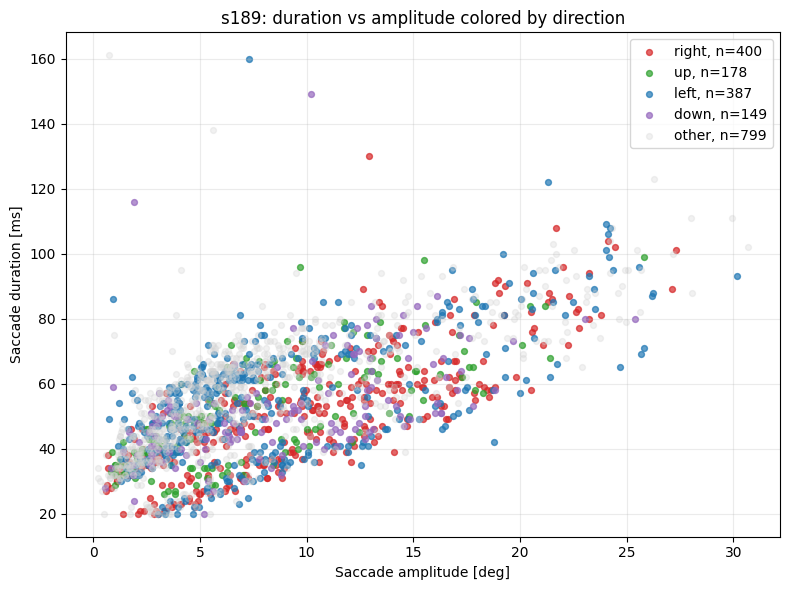

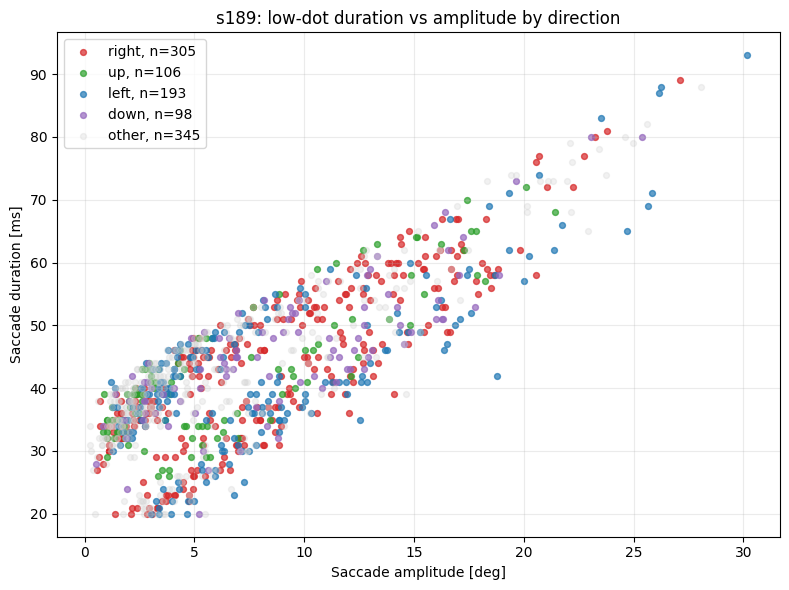

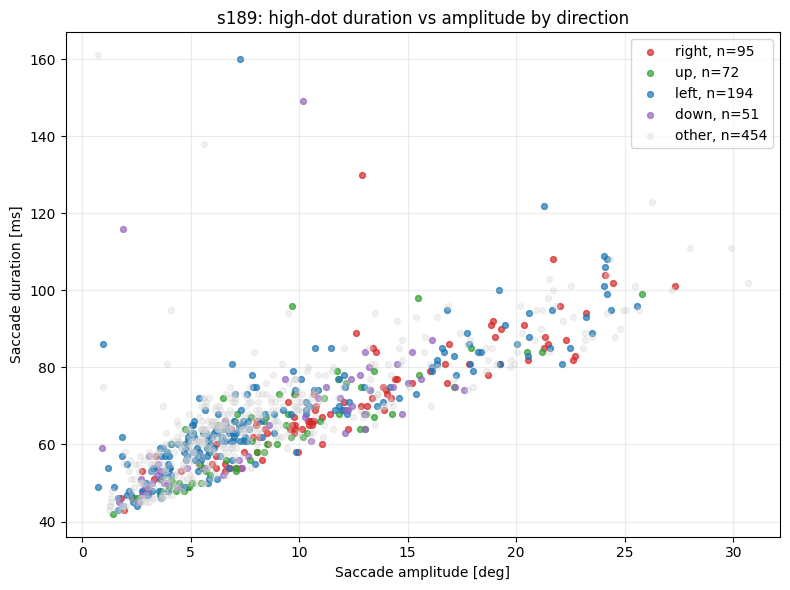

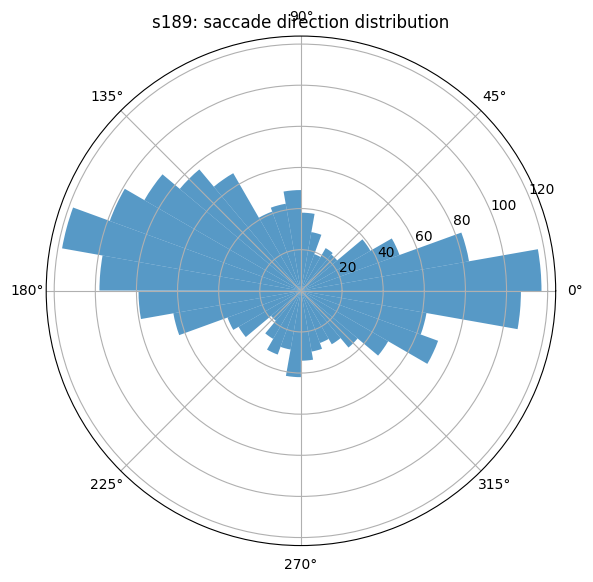

In [9]:
# ============================================================
# Saccade direction analysis from:
#   1) all_saccades_s189_band.csv
#   2) s189_trace_bank.pkl
#
# Adds:
#   start_x, start_y, end_x, end_y
#   dx, dy
#   direction_angle_rad
#   direction_angle_deg
#   direction_label = right/up/left/down/other
#
# Also plots:
#   duration vs amplitude colored by direction
# ============================================================

from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------

SUBJECT_ID = "s189"

OUT_DIR = Path("/content/drive/MyDrive/steer_search_PD/main_sequence_outputs")

SACCADE_BAND_PATH = OUT_DIR / f"all_saccades_{SUBJECT_ID}_band.csv"
TRACE_BANK_PATH = OUT_DIR / f"{SUBJECT_ID}_trace_bank.pkl"

OUT_PATH = OUT_DIR / f"all_saccades_{SUBJECT_ID}_band_direction.csv"

assert SACCADE_BAND_PATH.exists(), f"Missing: {SACCADE_BAND_PATH}"
assert TRACE_BANK_PATH.exists(), f"Missing: {TRACE_BANK_PATH}"

# ------------------------------------------------------------
# 2. Load files
# ------------------------------------------------------------

df_saccades = pd.read_csv(SACCADE_BAND_PATH)

with open(TRACE_BANK_PATH, "rb") as f:
    trace_bank = pickle.load(f)

print("Loaded saccades:", SACCADE_BAND_PATH)
print("Loaded trace bank:", TRACE_BANK_PATH)
print("Saccade rows:", len(df_saccades))
print("Trace bank entries:", len(trace_bank))

# ------------------------------------------------------------
# 3. Build trace key
# ------------------------------------------------------------

df_saccades["trace_key_for_bank"] = (
    df_saccades["subject_id"].astype(str) + "|" +
    df_saccades["block_id"].astype(str) + "|" +
    df_saccades["trial"].astype(int).astype(str) + "|" +
    df_saccades["saccade_index"].astype(int).astype(str)
)

n_match = df_saccades["trace_key_for_bank"].isin(trace_bank.keys()).sum()

print("Matching trace keys:", n_match, "/", len(df_saccades))

if n_match == 0:
    raise ValueError("No matching trace keys found.")


# ------------------------------------------------------------
# 4. Function requested: get_saccade_direction
# ------------------------------------------------------------

def get_saccade_direction(your_dataframe_saccades):
    """
    Returns saccade direction angles in radians.

    Required columns:
        start_x, start_y, end_x, end_y

    Angle convention:
        0 rad      = right
        +pi/2 rad  = up
        pi / -pi   = left
        -pi/2 rad  = down
    """

    required_cols = ["start_x", "start_y", "end_x", "end_y"]
    missing = [c for c in required_cols if c not in your_dataframe_saccades.columns]

    if missing:
        raise ValueError(f"Missing columns: {missing}")

    dx = (
        your_dataframe_saccades["end_x"].to_numpy(dtype=float)
        - your_dataframe_saccades["start_x"].to_numpy(dtype=float)
    )

    dy = (
        your_dataframe_saccades["end_y"].to_numpy(dtype=float)
        - your_dataframe_saccades["start_y"].to_numpy(dtype=float)
    )

    angles_rad = np.arctan2(dy, dx)

    return angles_rad


# ------------------------------------------------------------
# 5. Extract start/end x/y from trace bank
# ------------------------------------------------------------

def add_start_end_xy_from_trace_bank(
    df_saccades,
    trace_bank,
    n_samples_average=3,
    y_positive_up=True,
):
    """
    Adds start_x, start_y, end_x, end_y using trace_bank.

    Start = position around t_rel_ms = 0
    End   = position around t_rel_ms = duration_ms_from_time

    n_samples_average=3 averages nearby samples to reduce noise.
    Use 1 if you want exactly one closest sample.
    """

    df = df_saccades.copy()

    start_x = []
    start_y = []
    end_x = []
    end_y = []
    used = []

    half_window = max(0, int(n_samples_average // 2))

    for _, row in df.iterrows():

        key = row["trace_key_for_bank"]

        if key not in trace_bank:
            start_x.append(np.nan)
            start_y.append(np.nan)
            end_x.append(np.nan)
            end_y.append(np.nan)
            used.append(False)
            continue

        tr = trace_bank[key]

        t = np.asarray(tr["t_rel_ms"], dtype=float)
        x = np.asarray(tr["x_deg"], dtype=float)
        y = np.asarray(tr["y_deg"], dtype=float)

        if not (len(t) == len(x) == len(y)):
            start_x.append(np.nan)
            start_y.append(np.nan)
            end_x.append(np.nan)
            end_y.append(np.nan)
            used.append(False)
            continue

        # duration from trace bank preferred
        if "duration_ms_from_time" in tr and np.isfinite(tr["duration_ms_from_time"]):
            duration_ms = float(tr["duration_ms_from_time"])
        else:
            duration_ms = float(row["duration_ms"])

        # index closest to onset and offset
        i_start = int(np.nanargmin(np.abs(t - 0.0)))
        i_end = int(np.nanargmin(np.abs(t - duration_ms)))

        # average nearby samples to reduce single-sample noise
        s0 = max(0, i_start - half_window)
        s1 = min(len(t), i_start + half_window + 1)

        e0 = max(0, i_end - half_window)
        e1 = min(len(t), i_end + half_window + 1)

        sx = np.nanmean(x[s0:s1])
        sy = np.nanmean(y[s0:s1])
        ex = np.nanmean(x[e0:e1])
        ey = np.nanmean(y[e0:e1])

        # Flip y if your coordinate system is screen-style positive-down
        if not y_positive_up:
            sy = -sy
            ey = -ey

        start_x.append(sx)
        start_y.append(sy)
        end_x.append(ex)
        end_y.append(ey)
        used.append(True)

    df["start_x"] = start_x
    df["start_y"] = start_y
    df["end_x"] = end_x
    df["end_y"] = end_y
    df["xy_from_trace_bank"] = used

    return df


# ------------------------------------------------------------
# 6. Cardinal direction classifier
# ------------------------------------------------------------

def angle_diff_rad(a, b):
    """
    Circular angle difference.
    """
    return np.abs(np.arctan2(np.sin(a - b), np.cos(a - b)))


def classify_cardinal_directions(angles_rad, threshold_deg=10):
    """
    Classifies directions as:
        right, up, left, down, other

    threshold_deg:
        how close angle must be to a cardinal direction.

    Example:
        threshold_deg=22.5 means +/-22.5 degrees from right/up/left/down.
    """

    threshold_rad = np.deg2rad(threshold_deg)

    target_angles = {
        "right": 0.0,
        "up": np.pi / 2,
        "left": np.pi,
        "down": -np.pi / 2,
    }

    labels = []

    for angle in angles_rad:

        if not np.isfinite(angle):
            labels.append(np.nan)
            continue

        diffs = {
            label: angle_diff_rad(angle, target_angle)
            for label, target_angle in target_angles.items()
        }

        best_label = min(diffs, key=diffs.get)
        best_diff = diffs[best_label]

        if best_diff <= threshold_rad:
            labels.append(best_label)
        else:
            labels.append("other")

    return np.asarray(labels, dtype=object)


# ------------------------------------------------------------
# 7. Run direction extraction
# ------------------------------------------------------------

# If up/down look flipped in the final plot, change this to False.
Y_POSITIVE_UP = True

df_dir = add_start_end_xy_from_trace_bank(
    df_saccades=df_saccades,
    trace_bank=trace_bank,
    n_samples_average=3,
    y_positive_up=Y_POSITIVE_UP,
)

df_dir["dx"] = df_dir["end_x"] - df_dir["start_x"]
df_dir["dy"] = df_dir["end_y"] - df_dir["start_y"]

df_dir["direction_angle_rad"] = get_saccade_direction(df_dir)
df_dir["direction_angle_deg"] = np.rad2deg(df_dir["direction_angle_rad"])

df_dir["direction_label"] = classify_cardinal_directions(
    df_dir["direction_angle_rad"],
    threshold_deg=22.5,
)

# Optional: tiny saccades have noisy direction, so mark them as other.
MIN_AMP_FOR_DIRECTION = 0.5

df_dir.loc[
    df_dir["amplitude_deg"] < MIN_AMP_FOR_DIRECTION,
    "direction_label"
] = "other"

# ------------------------------------------------------------
# 8. Counts
# ------------------------------------------------------------

print("\nDirection counts:")
direction_counts = (
    df_dir["direction_label"]
    .value_counts(dropna=False)
    .rename_axis("direction_label")
    .reset_index(name="n")
)

display(direction_counts)

print("\nDirection percentages:")
direction_percent = (
    df_dir["direction_label"]
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .round(2)
    .rename_axis("direction_label")
    .reset_index(name="percent")
)

display(direction_percent)

cardinal_labels = ["right", "up", "left", "down"]

df_dir["is_cardinal_direction"] = df_dir["direction_label"].isin(cardinal_labels)

print("\nCardinal vs other:")
cardinal_summary = (
    df_dir["is_cardinal_direction"]
    .value_counts(dropna=False)
    .rename_axis("is_cardinal_direction")
    .reset_index(name="n")
)

display(cardinal_summary)

print("\nCardinal vs other percentages:")
cardinal_percent = (
    df_dir["is_cardinal_direction"]
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .round(2)
    .rename_axis("is_cardinal_direction")
    .reset_index(name="percent")
)

display(cardinal_percent)

# ------------------------------------------------------------
# 9. Save output
# ------------------------------------------------------------

df_dir.to_csv(OUT_PATH, index=False)

print("\nSaved direction CSV:")
print(OUT_PATH)

# ------------------------------------------------------------
# 10. Duration vs amplitude colored by direction
# ------------------------------------------------------------

direction_color_map = {
    "right": "tab:red",
    "up": "tab:green",
    "left": "tab:blue",
    "down": "tab:purple",
    "other": "lightgray",
}

plt.figure(figsize=(8, 6))

for label in ["right", "up", "left", "down", "other"]:

    temp = df_dir[df_dir["direction_label"] == label].copy()

    if len(temp) == 0:
        continue

    plt.scatter(
        temp["amplitude_deg"],
        temp["duration_ms"],
        s=18,
        alpha=0.70 if label != "other" else 0.30,
        color=direction_color_map[label],
        label=f"{label}, n={len(temp)}",
    )

plt.xlabel("Saccade amplitude [deg]")
plt.ylabel("Saccade duration [ms]")
plt.title(f"{SUBJECT_ID}: duration vs amplitude colored by direction")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 11. Same plot but separated by low-dot / high-dot
# ------------------------------------------------------------

if "band_label" in df_dir.columns:

    for band in ["low-dot", "high-dot"]:

        temp_band = df_dir[df_dir["band_label"] == band].copy()

        if len(temp_band) == 0:
            continue

        plt.figure(figsize=(8, 6))

        for label in ["right", "up", "left", "down", "other"]:

            temp = temp_band[temp_band["direction_label"] == label].copy()

            if len(temp) == 0:
                continue

            plt.scatter(
                temp["amplitude_deg"],
                temp["duration_ms"],
                s=18,
                alpha=0.70 if label != "other" else 0.30,
                color=direction_color_map[label],
                label=f"{label}, n={len(temp)}",
            )

        plt.xlabel("Saccade amplitude [deg]")
        plt.ylabel("Saccade duration [ms]")
        plt.title(f"{SUBJECT_ID}: {band} duration vs amplitude by direction")
        plt.legend()
        plt.grid(alpha=0.25)
        plt.tight_layout()
        plt.show()

# ------------------------------------------------------------
# 12. Polar histogram of all saccade directions
# ------------------------------------------------------------

valid_angles = df_dir["direction_angle_rad"].dropna().to_numpy(dtype=float)

plt.figure(figsize=(6, 6))
ax = plt.subplot(111, projection="polar")

ax.hist(
    valid_angles,
    bins=36,
    alpha=0.75,
)

ax.set_title(f"{SUBJECT_ID}: saccade direction distribution")
plt.tight_layout()
plt.show()

Raw counts:


direction_label,down,left,other,right,up
band_label,,,,,
high-dot,51,194,454,95,72
low-dot,98,193,345,305,106


Percent within each band:


direction_label,down,left,other,right,up
band_label,,,,,
high-dot,5.89,22.40,52.42,10.97,8.31
low-dot,9.36,18.43,32.95,29.13,10.12


Right-left counts:


direction_label,left,right
band_label,,
high-dot,194,95
low-dot,193,305


Right-left percent within band:


direction_label,left,right
band_label,,
high-dot,67.13,32.87
low-dot,38.76,61.24


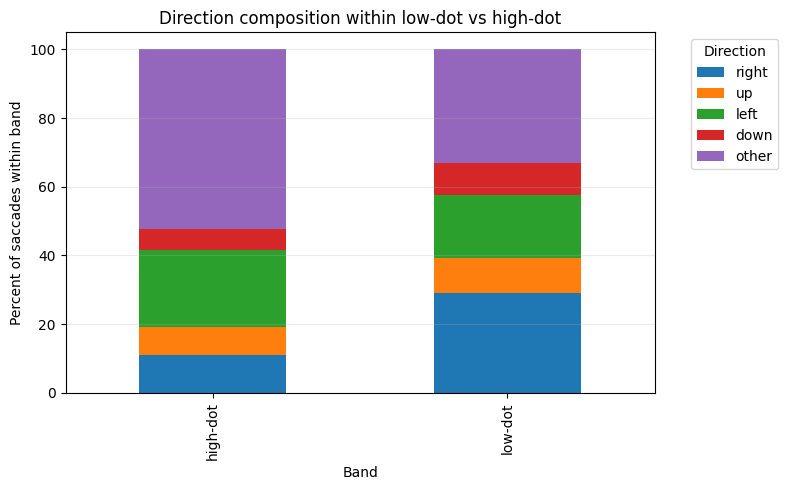

direction_label,left,right
band_label,,
high-dot,194,95
low-dot,193,305


Fisher exact test
odds ratio: 3.227161167166621
p-value: 1.613889069239316e-14

Chi-square test
chi2: 57.77382231781798
p-value: 2.9405714072114306e-14
dof: 1


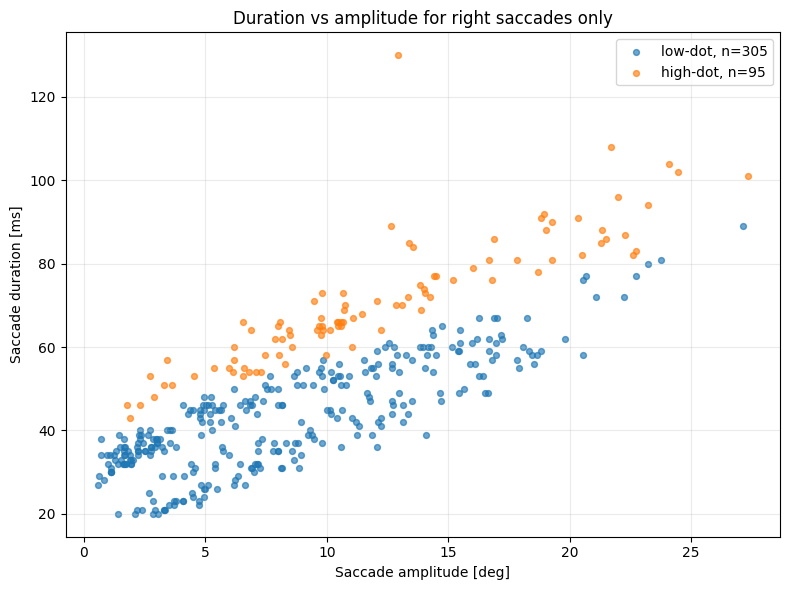

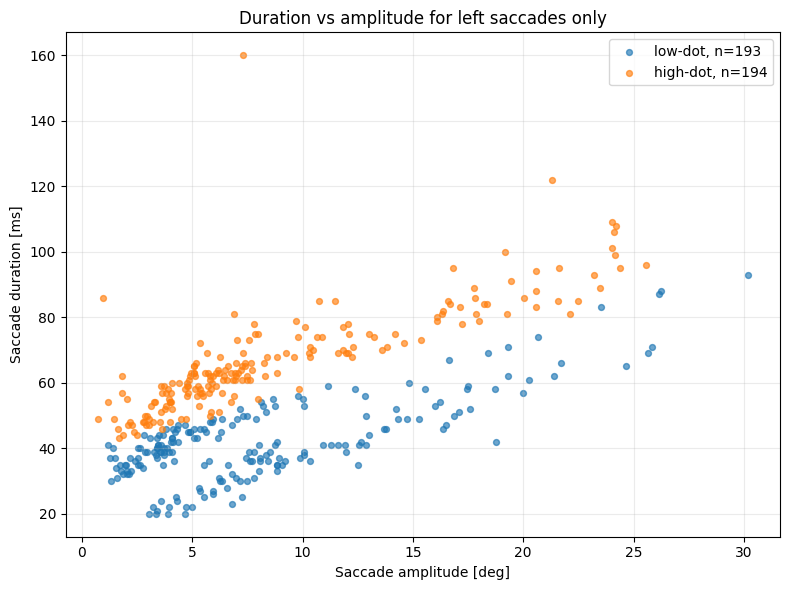

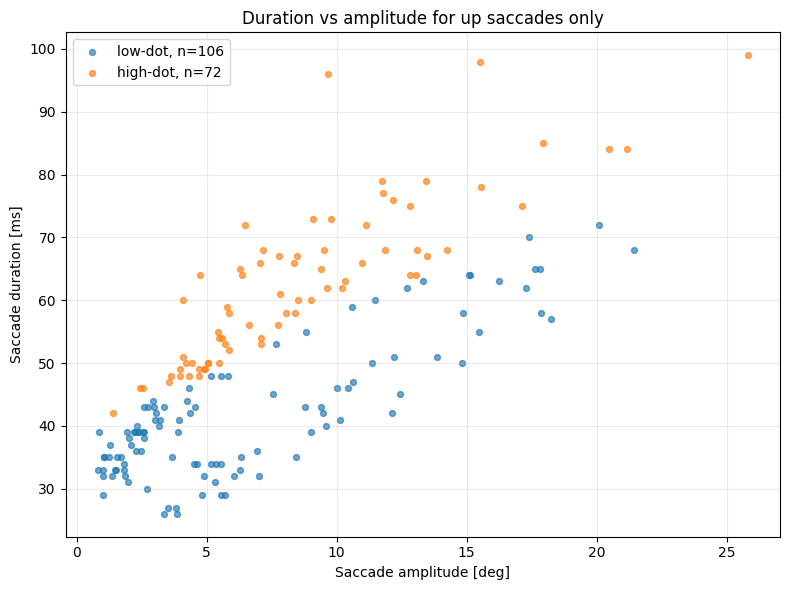

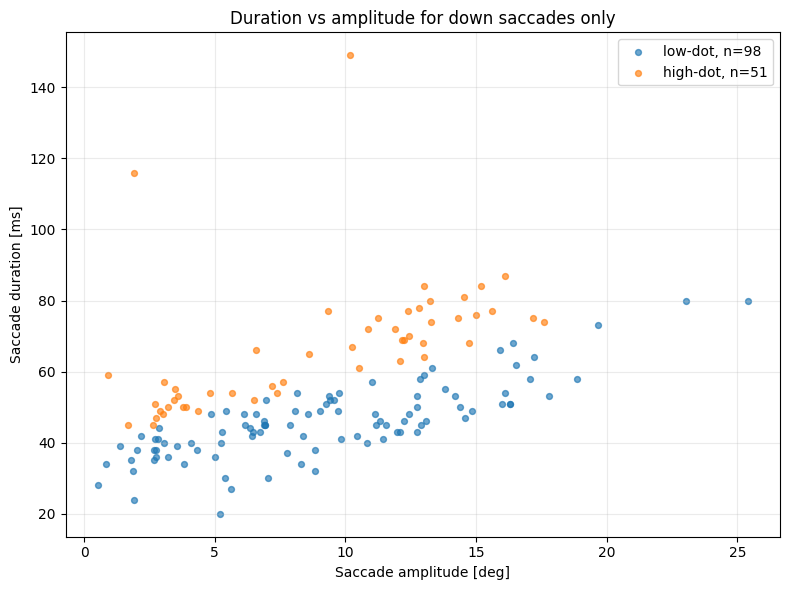

In [12]:
# ============================================================
# Direction x band summary
# Run after df_dir exists
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Counts: band_label x direction_label
# ------------------------------------------------------------

ct = pd.crosstab(
    df_dir["band_label"],
    df_dir["direction_label"],
    dropna=False
)

print("Raw counts:")
display(ct)

# ------------------------------------------------------------
# 2. Percent within each band
# ------------------------------------------------------------

ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

print("Percent within each band:")
display(ct_pct.round(2))

# ============================================================
# Right-vs-left only
# ============================================================

rl = df_dir[df_dir["direction_label"].isin(["right", "left"])].copy()

rl_ct = pd.crosstab(
    rl["band_label"],
    rl["direction_label"]
)

print("Right-left counts:")
display(rl_ct)

rl_pct = rl_ct.div(rl_ct.sum(axis=1), axis=0) * 100

print("Right-left percent within band:")
display(rl_pct.round(2))

# ============================================================
# Stacked bar plot: direction composition by band
# ============================================================

direction_order = ["right", "up", "left", "down", "other"]

ct_plot = ct.reindex(columns=direction_order, fill_value=0)
ct_plot_pct = ct_plot.div(ct_plot.sum(axis=1), axis=0) * 100

ax = ct_plot_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.ylabel("Percent of saccades within band")
plt.xlabel("Band")
plt.title("Direction composition within low-dot vs high-dot")
plt.legend(title="Direction", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

from scipy.stats import fisher_exact, chi2_contingency

# Need exactly two bands and two directions
rl_ct = pd.crosstab(
    rl["band_label"],
    rl["direction_label"]
)

display(rl_ct)

# Fisher exact test for 2x2 table
oddsratio, p_fisher = fisher_exact(rl_ct)

print("Fisher exact test")
print("odds ratio:", oddsratio)
print("p-value:", p_fisher)

# Chi-square test also okay if counts are large
chi2, p_chi2, dof, expected = chi2_contingency(rl_ct)

print("\nChi-square test")
print("chi2:", chi2)
print("p-value:", p_chi2)
print("dof:", dof)

# ============================================================
# Duration-amplitude plot split by direction
# ============================================================

for direction in ["right", "left", "up", "down"]:

    temp_dir = df_dir[df_dir["direction_label"] == direction].copy()

    if len(temp_dir) == 0:
        continue

    plt.figure(figsize=(8, 6))

    for band in ["low-dot", "high-dot"]:
        temp = temp_dir[temp_dir["band_label"] == band]

        if len(temp) == 0:
            continue

        plt.scatter(
            temp["amplitude_deg"],
            temp["duration_ms"],
            s=18,
            alpha=0.65,
            label=f"{band}, n={len(temp)}"
        )

    plt.xlabel("Saccade amplitude [deg]")
    plt.ylabel("Saccade duration [ms]")
    plt.title(f"Duration vs amplitude for {direction} saccades only")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

#The two bands are real in duration-amplitude space for s189. They persist within right, left, up, and down saccades. But the bands are directionally imbalanced: low-dot is enriched for rightward saccades, and high-dot is enriched for leftward saccades. This suggests a direction-dependent asymmetry in the saccade dynamics, calibration, or segmentation, rather than a purely random two-band artifact.

Using fs = 1000.0


,n,median_amp,median_duration,median_peak_velocity,median_mean_speed,median_peak_to_mean
band_label,,,,,,
high-dot,866,7.101626,64.0,436.543757,112.721345,3.859204
low-dot,1047,5.674452,41.0,389.583843,154.223037,2.547203


,n,median_duration,median_time_to_peak,median_peak_to_offset,median_peak_velocity,median_mean_speed
band_label,,,,,,
high-dot,866,64.0,13.0,51.0,436.543757,112.721345
low-dot,1047,41.0,13.0,28.0,389.583843,154.223037


Available:


,0
band_label,
high-dot,10
low-dot,35


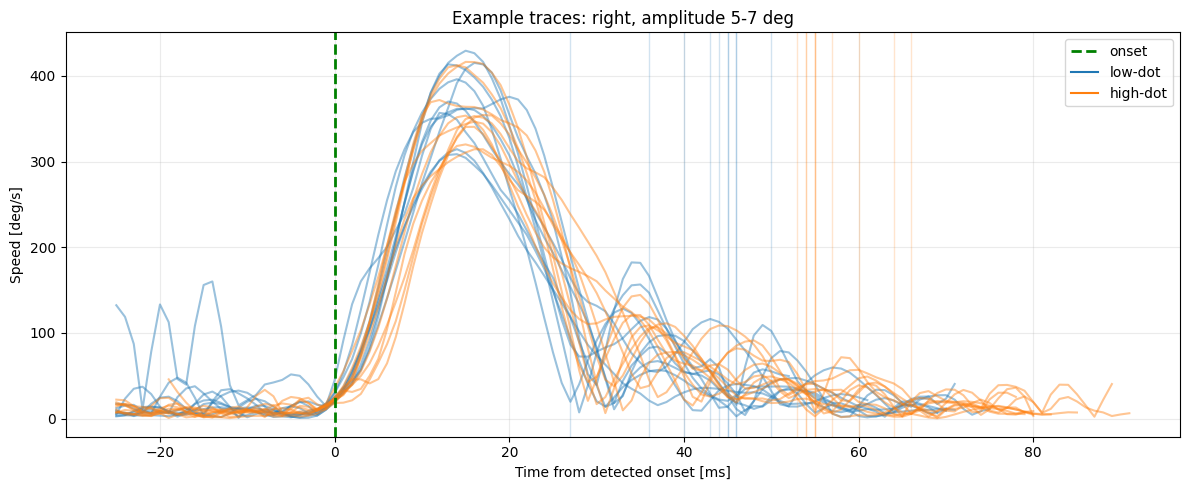

Available:


,0
band_label,
high-dot,48
low-dot,28


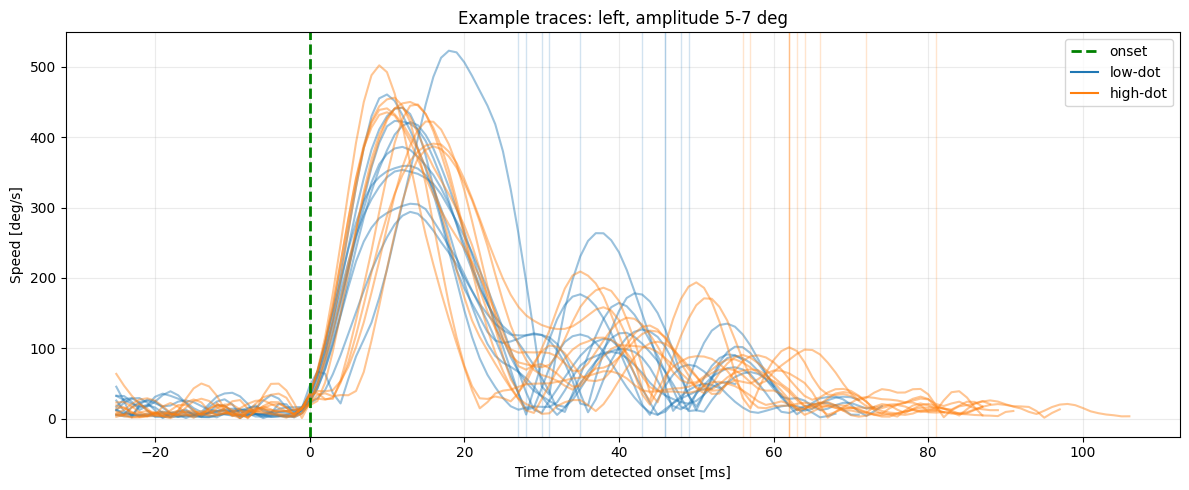

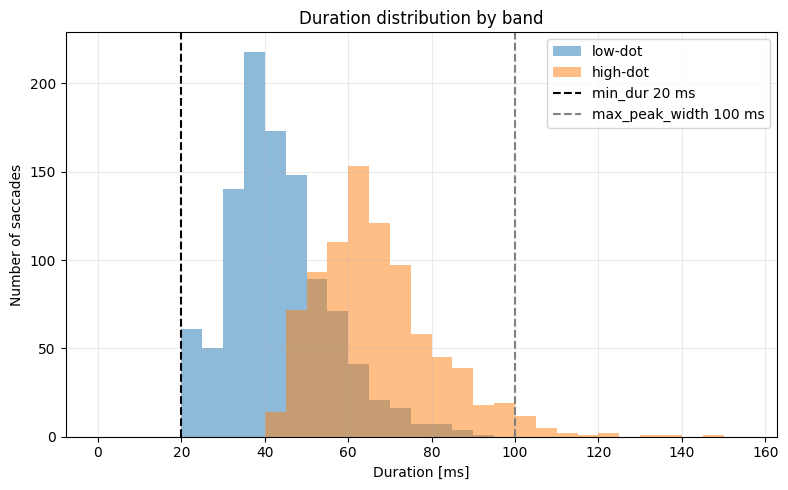

In [14]:
# ============================================================
# Segmentation-artifact diagnostic summary
# Run after df_dir exists
# ============================================================

# ------------------------------------------------------------
# Get sampling rate from trace bank
# ------------------------------------------------------------

first_key = next(iter(trace_bank.keys()))
fs = float(trace_bank[first_key]["fs"])

print("Using fs =", fs)

from dataclasses import dataclass

@dataclass(frozen=True)
class SegmentationParams:
    fs: float = 1200.0
    winsize: int = 41
    sg_poly_order: int = 3

    min_saccade_speed: float = 10.0 / 60.0
    start_vel: float = 6.0 / 60.0
    min_peak_width_s: float = 10e-3
    max_peak_width_s: float = 100e-3
    min_peak_prominence: float = 10.0 / 60.0

    min_gap_s: float = 15e-3
    min_dur_s: float = 20e-3
    max_dur_s: float = 300e-3

    min_amp_deg: float = 10.0 / 60.0
    microsaccade_amp_deg_max: float = 30.0 / 60.0

    drift_min_duration_ms: float = 50.0
    drift_max_speed: float = 500.0 / 60.0

    curvature_clip: float = 300.0
    short_gap_max_samples: int = 5
    blink_pad_samples: int = 5


df_seg = df_dir.dropna(subset=["band_label", "amplitude_deg", "duration_ms"]).copy()

df_seg["mean_speed_deg_s"] = (
    df_seg["amplitude_deg"] / (df_seg["duration_ms"] / 1000.0)
)

df_seg["peak_to_mean_ratio"] = (
    df_seg["peak_velocity_deg_s"] / df_seg["mean_speed_deg_s"]
)

summary = (
    df_seg
    .groupby("band_label")
    .agg(
        n=("band_label", "size"),
        median_amp=("amplitude_deg", "median"),
        median_duration=("duration_ms", "median"),
        median_peak_velocity=("peak_velocity_deg_s", "median"),
        median_mean_speed=("mean_speed_deg_s", "median"),
        median_peak_to_mean=("peak_to_mean_ratio", "median"),
    )
)

display(summary)

# ============================================================
# For each trace, compute time from peak speed to detected offset
# ============================================================

rows = []

for _, row in df_dir.dropna(subset=["band_label"]).iterrows():

    key = row["trace_key_for_bank"]

    if key not in trace_bank:
        continue

    tr = trace_bank[key]

    t = np.asarray(tr["t_rel_ms"], dtype=float)
    speed = np.asarray(tr["speed_deg_s"], dtype=float)

    duration_ms = float(tr.get("duration_ms_from_time", row["duration_ms"]))

    if len(t) == 0 or len(speed) == 0:
        continue

    # only consider detected saccade interval
    in_saccade = (t >= 0) & (t <= duration_ms)

    if in_saccade.sum() < 3:
        continue

    t_sac = t[in_saccade]
    speed_sac = speed[in_saccade]

    peak_i = np.nanargmax(speed_sac)
    t_peak = t_sac[peak_i]

    rows.append({
        "trace_key": key,
        "band_label": row["band_label"],
        "direction_label": row.get("direction_label", np.nan),
        "amplitude_deg": row["amplitude_deg"],
        "duration_ms": duration_ms,
        "peak_velocity_deg_s": np.nanmax(speed_sac),
        "time_to_peak_ms": t_peak,
        "peak_to_offset_ms": duration_ms - t_peak,
        "mean_speed_deg_s": row["amplitude_deg"] / (duration_ms / 1000.0),
    })

peak_df = pd.DataFrame(rows)

display(
    peak_df
    .groupby("band_label")
    .agg(
        n=("trace_key", "count"),
        median_duration=("duration_ms", "median"),
        median_time_to_peak=("time_to_peak_ms", "median"),
        median_peak_to_offset=("peak_to_offset_ms", "median"),
        median_peak_velocity=("peak_velocity_deg_s", "median"),
        median_mean_speed=("mean_speed_deg_s", "median"),
    )
)

# ============================================================
# Plot example traces from same amplitude bin and direction
# ============================================================

import matplotlib.pyplot as plt

def plot_example_traces_same_amp_direction(
    df_dir,
    trace_bank,
    direction="right",
    amp_min=5,
    amp_max=7,
    n_each=8,
    random_state=42,
):
    temp = df_dir[
        (df_dir["direction_label"] == direction)
        & (df_dir["amplitude_deg"] >= amp_min)
        & (df_dir["amplitude_deg"] < amp_max)
        & (df_dir["band_label"].isin(["low-dot", "high-dot"]))
    ].copy()

    print("Available:")
    display(temp.groupby("band_label").size())

    parts = []

    for band in ["low-dot", "high-dot"]:
        d = temp[temp["band_label"] == band]

        if len(d) == 0:
            continue

        d = d.sample(
            n=min(n_each, len(d)),
            random_state=random_state
        )

        parts.append(d)

    if len(parts) == 0:
        print("No traces found.")
        return

    sample_df = pd.concat(parts)

    color_map = {
        "low-dot": "tab:blue",
        "high-dot": "tab:orange",
    }

    plt.figure(figsize=(12, 5))

    for _, row in sample_df.iterrows():
        key = row["trace_key_for_bank"]

        if key not in trace_bank:
            continue

        tr = trace_bank[key]

        t = np.asarray(tr["t_rel_ms"], dtype=float)
        speed = np.asarray(tr["speed_deg_s"], dtype=float)

        duration_ms = float(tr.get("duration_ms_from_time", row["duration_ms"]))

        keep = (t >= -25) & (t <= duration_ms + 25)

        plt.plot(
            t[keep],
            speed[keep],
            color=color_map[row["band_label"]],
            alpha=0.45,
            linewidth=1.5,
        )

        # detected offset
        plt.axvline(
            duration_ms,
            color=color_map[row["band_label"]],
            alpha=0.20,
            linewidth=1,
        )

    plt.axvline(0, color="green", linestyle="--", linewidth=2, label="onset")
    plt.xlabel("Time from detected onset [ms]")
    plt.ylabel("Speed [deg/s]")
    plt.title(
        f"Example traces: {direction}, amplitude {amp_min}-{amp_max} deg"
    )

    plt.plot([], [], color="tab:blue", label="low-dot")
    plt.plot([], [], color="tab:orange", label="high-dot")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


plot_example_traces_same_amp_direction(
    df_dir=df_dir,
    trace_bank=trace_bank,
    direction="right",
    amp_min=5,
    amp_max=7,
    n_each=10,
)

plot_example_traces_same_amp_direction(
    df_dir=df_dir,
    trace_bank=trace_bank,
    direction="left",
    amp_min=5,
    amp_max=7,
    n_each=10,
)

plt.figure(figsize=(8, 5))

for band in ["low-dot", "high-dot"]:
    d = df_dir[df_dir["band_label"] == band]
    plt.hist(
        d["duration_ms"],
        bins=np.arange(0, 160, 5),
        alpha=0.5,
        label=band
    )

plt.axvline(20, color="black", linestyle="--", label="min_dur 20 ms")
plt.axvline(100, color="gray", linestyle="--", label="max_peak_width 100 ms")
plt.xlabel("Duration [ms]")
plt.ylabel("Number of saccades")
plt.title("Duration distribution by band")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

params_list = [
    ("default", SegmentationParams(fs=fs)),
    ("smaller_winsize", SegmentationParams(fs=fs, winsize=13)),
    ("higher_start_vel", SegmentationParams(fs=fs, start_vel=12.0 / 60.0)),
    ("lower_start_vel", SegmentationParams(fs=fs, start_vel=3.0 / 60.0)),
    ("no_short_gap_merge", SegmentationParams(fs=fs, short_gap_max_samples=0)),
]

,n,median_amp,median_seg_duration,median_duration_90,median_duration_95,median_peak_velocity
band_label,,,,,,
high-dot,866,7.101626,64.0,26.0,28.0,436.543757
low-dot,1047,5.674452,41.0,22.0,23.0,389.583843


duration_90 > duration_seg count: 0
duration_95 > duration_seg count: 0


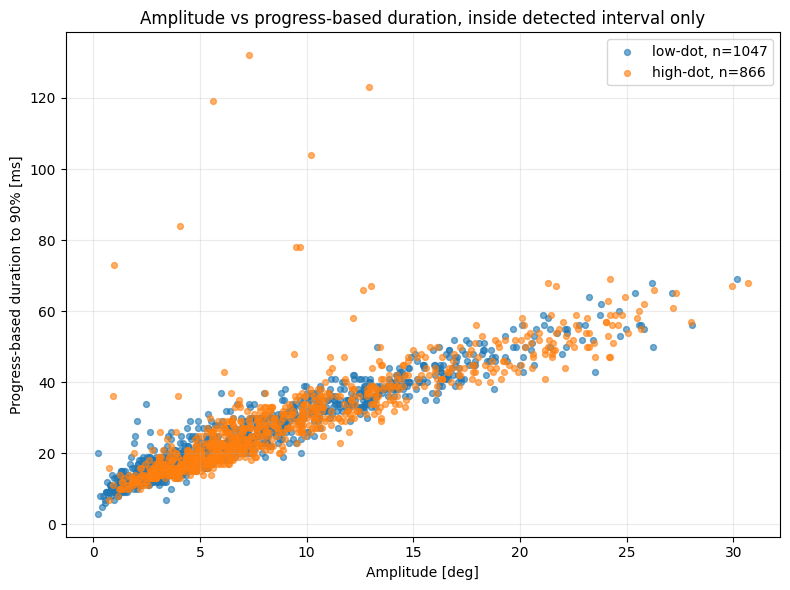

,n,median_seg_duration,median_duration_90,median_duration_95,median_tail_after_90,median_tail_after_95
band_label,,,,,,
high-dot,866,64.0,26.0,28.0,38.0,36.0
low-dot,1047,41.0,22.0,23.0,21.0,20.0


In [18]:
# ============================================================
# Corrected progress-based duration
# Only uses samples inside detected saccade interval:
#   0 <= t_rel_ms <= duration_ms
#
# This prevents later unrelated movements from affecting duration_90/95.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rows = []

for _, row in df_dir.dropna(subset=["band_label"]).iterrows():

    key = row["trace_key_for_bank"]

    if key not in trace_bank:
        continue

    tr = trace_bank[key]

    t = np.asarray(tr["t_rel_ms"], dtype=float)
    progress = np.asarray(tr["progress_deg"], dtype=float)

    if len(t) != len(progress):
        continue

    duration_ms = float(tr.get("duration_ms_from_time", row["duration_ms"]))

    # IMPORTANT:
    # Only use the detected saccade interval.
    keep = (t >= 0) & (t <= duration_ms)

    t_sac = t[keep]
    p_sac = progress[keep]

    if len(t_sac) < 5:
        continue

    # Use progress at detected offset, not max over the whole trace.
    final_progress = p_sac[-1]

    if not np.isfinite(final_progress) or final_progress <= 0:
        continue

    p90 = 0.90 * final_progress
    p95 = 0.95 * final_progress

    idx90 = np.where(p_sac >= p90)[0]
    idx95 = np.where(p_sac >= p95)[0]

    if len(idx90) == 0 or len(idx95) == 0:
        continue

    duration_90_ms = t_sac[idx90[0]]
    duration_95_ms = t_sac[idx95[0]]

    rows.append({
        "trace_key": key,
        "band_label": row["band_label"],
        "direction_label": row.get("direction_label", np.nan),
        "amplitude_deg": row["amplitude_deg"],
        "duration_seg_ms": duration_ms,
        "duration_90_ms": duration_90_ms,
        "duration_95_ms": duration_95_ms,
        "peak_velocity_deg_s": row["peak_velocity_deg_s"],
    })

progress_df = pd.DataFrame(rows)

display(
    progress_df
    .groupby("band_label")
    .agg(
        n=("trace_key", "count"),
        median_amp=("amplitude_deg", "median"),
        median_seg_duration=("duration_seg_ms", "median"),
        median_duration_90=("duration_90_ms", "median"),
        median_duration_95=("duration_95_ms", "median"),
        median_peak_velocity=("peak_velocity_deg_s", "median"),
    )
)

# Sanity check:
# progress duration should not exceed segmentation duration
print("duration_90 > duration_seg count:",
      (progress_df["duration_90_ms"] > progress_df["duration_seg_ms"]).sum())

print("duration_95 > duration_seg count:",
      (progress_df["duration_95_ms"] > progress_df["duration_seg_ms"]).sum())

plt.figure(figsize=(8, 6))

for band in ["low-dot", "high-dot"]:
    d = progress_df[progress_df["band_label"] == band]

    plt.scatter(
        d["amplitude_deg"],
        d["duration_90_ms"],
        s=18,
        alpha=0.6,
        label=f"{band}, n={len(d)}"
    )

plt.xlabel("Amplitude [deg]")
plt.ylabel("Progress-based duration to 90% [ms]")
plt.title("Amplitude vs progress-based duration, inside detected interval only")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

progress_df["tail_after_90_ms"] = (
    progress_df["duration_seg_ms"] - progress_df["duration_90_ms"]
)

progress_df["tail_after_95_ms"] = (
    progress_df["duration_seg_ms"] - progress_df["duration_95_ms"]
)

display(
    progress_df
    .groupby("band_label")
    .agg(
        n=("trace_key", "count"),
        median_seg_duration=("duration_seg_ms", "median"),
        median_duration_90=("duration_90_ms", "median"),
        median_duration_95=("duration_95_ms", "median"),
        median_tail_after_90=("tail_after_90_ms", "median"),
        median_tail_after_95=("tail_after_95_ms", "median"),
    )
)